# Sensor Capture Data Exploration

This notebook explores a CARLA sensor capture folder containing camera images and synchronized CSV outputs.

It includes:
- dataset inventory and file integrity checks
- schema and missing-value analysis
- descriptive statistics
- camera/radar alignment diagnostics
- quick visualizations

In [19]:
from pathlib import Path
from collections import Counter
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [20]:
# Update this path if you want to explore a different capture folder.
DATASET_DIR = Path(r"C:\Users\Colin\Downloads\CARLA_Latest\Scripts\DatasetCreation\sensor_capture_20260325_183350")
CAMERA_FRAMES_DIR = DATASET_DIR / "camera_frames"
CAMERA_CSV = DATASET_DIR / "camera_data.csv"
RADAR_CSV = DATASET_DIR / "radar_data.csv"

assert DATASET_DIR.exists(), f"Dataset directory not found: {DATASET_DIR}"
assert CAMERA_FRAMES_DIR.exists(), f"camera_frames not found: {CAMERA_FRAMES_DIR}"
assert CAMERA_CSV.exists(), f"Missing file: {CAMERA_CSV}"
assert RADAR_CSV.exists(), f"Missing file: {RADAR_CSV}"

DATASET_DIR

WindowsPath('C:/Users/Colin/Downloads/CARLA_Latest/Scripts/DatasetCreation/sensor_capture_20260325_183350')

In [21]:
def file_size_mb(path: Path) -> float:
    return path.stat().st_size / (1024 * 1024)

png_paths = sorted(CAMERA_FRAMES_DIR.rglob("*.png"))
ext_counter = Counter(p.suffix.lower() for p in CAMERA_FRAMES_DIR.rglob("*") if p.is_file())

inventory = pd.DataFrame(
    [
        {"item": "camera_frames (png count)", "value": len(png_paths)},
        {"item": "camera_data.csv size (MB)", "value": round(file_size_mb(CAMERA_CSV), 3)},
        {"item": "radar_data.csv size (MB)", "value": round(file_size_mb(RADAR_CSV), 3)},
        {
            "item": "camera_frames total size (MB)",
            "value": round(sum(p.stat().st_size for p in png_paths) / (1024 * 1024), 3),
        },
    ]
)

display(inventory)
display(pd.DataFrame([{"extension": k, "count": v} for k, v in sorted(ext_counter.items())]))

if png_paths:
    print("Sample image paths:")
    for p in png_paths[:5]:
        print(" -", p)

,item,value
0,camera_frames (png count),686.000
1,camera_data.csv size (MB),0.120
2,radar_data.csv size (MB),13.394
3,camera_frames total size (MB),543.772


,extension,count
0,.png,686


Sample image paths:
 - C:\Users\Colin\Downloads\CARLA_Latest\Scripts\DatasetCreation\sensor_capture_20260325_183350\camera_frames\camera_75\frame_00259918.png
 - C:\Users\Colin\Downloads\CARLA_Latest\Scripts\DatasetCreation\sensor_capture_20260325_183350\camera_frames\camera_75\frame_00259919.png
 - C:\Users\Colin\Downloads\CARLA_Latest\Scripts\DatasetCreation\sensor_capture_20260325_183350\camera_frames\camera_75\frame_00259936.png
 - C:\Users\Colin\Downloads\CARLA_Latest\Scripts\DatasetCreation\sensor_capture_20260325_183350\camera_frames\camera_75\frame_00259953.png
 - C:\Users\Colin\Downloads\CARLA_Latest\Scripts\DatasetCreation\sensor_capture_20260325_183350\camera_frames\camera_75\frame_00259970.png


In [22]:
camera_df = pd.read_csv(CAMERA_CSV)
radar_df = pd.read_csv(RADAR_CSV)

print("camera_data shape:", camera_df.shape)
print("radar_data shape:", radar_df.shape)

display(camera_df.head(3))
display(radar_df.head(3))

camera_data shape: (685, 9)
radar_data shape: (187290, 10)


,sensor_id,frame,timestamp,width,height,image_path,nearest_vehicle_id,nearest_vehicle_distance_m,nearby_vehicle_ids
0,75,259918,1543.280794,800,600,C:\Users\Colin\Downloads\CARLA_Latest\Scripts\...,80,34.975653,80
1,75,259919,1543.288698,800,600,C:\Users\Colin\Downloads\CARLA_Latest\Scripts\...,80,34.081441,80
2,75,259936,1543.420450,800,600,C:\Users\Colin\Downloads\CARLA_Latest\Scripts\...,80,33.352292,80


,sensor_id,frame,timestamp,detection_index,depth_m,azimuth_rad,altitude_rad,velocity_mps,matched_vehicle_id,matched_vehicle_distance_m
0,28,259740,1541.895191,0,6.810290,0.026965,-0.106658,4.606656,80,1.830754
1,28,259740,1541.895191,2,6.376394,-0.067035,-0.124180,3.983742,80,1.248378
2,28,259740,1541.895191,4,6.562727,-0.073843,-0.132675,3.933550,80,1.155530


In [23]:
def missing_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    out = pd.DataFrame(
        {
            "column": df.columns,
            "missing_count": [int(df[c].isna().sum()) for c in df.columns],
        }
    )
    out["missing_pct"] = (out["missing_count"] / len(df) * 100).round(3)
    out.insert(0, "table", name)
    return out

missing_df = pd.concat(
    [missing_report(camera_df, "camera_data"), missing_report(radar_df, "radar_data")],
    ignore_index=True,
)

display(missing_df)
print("Total missing values in camera_data:", int(camera_df.isna().sum().sum()))
print("Total missing values in radar_data:", int(radar_df.isna().sum().sum()))

,table,column,missing_count,missing_pct
0,camera_data,sensor_id,0,0.0
1,camera_data,frame,0,0.0
2,camera_data,timestamp,0,0.0
3,camera_data,width,0,0.0
4,camera_data,height,0,0.0
5,camera_data,image_path,0,0.0
6,camera_data,nearest_vehicle_id,0,0.0
7,camera_data,nearest_vehicle_distance_m,0,0.0
8,camera_data,nearby_vehicle_ids,0,0.0
9,radar_data,sensor_id,0,0.0


Total missing values in camera_data: 0
Total missing values in radar_data: 0


In [24]:
# Numeric conversions
camera_num = camera_df.copy()
radar_num = radar_df.copy()

for c in ["frame", "timestamp", "width", "height", "nearest_vehicle_distance_m"]:
    if c in camera_num.columns:
        camera_num[c] = pd.to_numeric(camera_num[c], errors="coerce")

for c in [
    "frame",
    "timestamp",
    "detection_index",
    "depth_m",
    "azimuth_rad",
    "altitude_rad",
    "velocity_mps",
    "matched_vehicle_distance_m",
]:
    if c in radar_num.columns:
        radar_num[c] = pd.to_numeric(radar_num[c], errors="coerce")

camera_stats = camera_num[["frame", "timestamp", "nearest_vehicle_distance_m"]].describe().T
radar_stats = radar_num[["frame", "timestamp", "depth_m", "velocity_mps", "matched_vehicle_distance_m"]].describe().T

print("Camera numeric summary")
display(camera_stats)

print("Radar numeric summary")
display(radar_stats)

Camera numeric summary


,count,mean,std,min,25%,50%,75%,max
frame,685.0,270209.637956,6201.635597,259918.000000,265612.000000,268833.000000,277114.000000,279263.000000
timestamp,685.0,1641.204029,63.188009,1543.280794,1593.118222,1623.896050,1711.811332,1737.064390
nearest_vehicle_distance_m,685.0,15.461486,8.573232,0.585648,8.196154,16.011583,21.202822,34.984184


Radar numeric summary


,count,mean,std,min,25%,50%,75%,max
frame,187290.0,271570.501271,5987.122908,259740.000000,266527.000000,269534.000000,277717.000000,279299.000000
timestamp,187290.0,1654.934000,61.724774,1541.895191,1601.811071,1630.970120,1718.789308,1737.495986
depth_m,187290.0,12.736698,6.410291,3.866057,6.714482,10.689854,18.557864,29.869543
velocity_mps,187290.0,2.809491,1.969390,-0.297792,0.000000,3.609075,4.342138,6.763572
matched_vehicle_distance_m,187290.0,2.503930,1.214049,0.013750,1.612522,2.159943,3.012866,5.999965


In [25]:
# Frame-level alignment checks
camera_frames = set(camera_num["frame"].dropna().astype(int).tolist())
radar_frames = set(radar_num["frame"].dropna().astype(int).tolist())

common_frames = camera_frames & radar_frames
camera_only_frames = camera_frames - radar_frames
radar_only_frames = radar_frames - camera_frames

png_frame_ids = set()
for p in png_paths:
    stem = p.stem  # e.g. frame_00259918
    if stem.startswith("frame_"):
        try:
            png_frame_ids.add(int(stem.split("_")[1]))
        except ValueError:
            pass

csv_without_png = sorted(list(camera_frames - png_frame_ids))
png_without_csv = sorted(list(png_frame_ids - camera_frames))

alignment_summary = pd.DataFrame(
    [
        {"metric": "camera unique frames", "value": len(camera_frames)},
        {"metric": "radar unique frames", "value": len(radar_frames)},
        {"metric": "common frames", "value": len(common_frames)},
        {"metric": "camera-only frames", "value": len(camera_only_frames)},
        {"metric": "radar-only frames", "value": len(radar_only_frames)},
        {"metric": "camera CSV frames without PNG", "value": len(csv_without_png)},
        {"metric": "PNG frames without camera CSV row", "value": len(png_without_csv)},
    ]
)

display(alignment_summary)
print("Sample camera CSV frames without PNG:", csv_without_png[:10])
print("Sample PNG frames without camera CSV row:", png_without_csv[:10])

,metric,value
0,camera unique frames,685
1,radar unique frames,8664
2,common frames,531
3,camera-only frames,154
4,radar-only frames,8133
5,camera CSV frames without PNG,0
6,PNG frames without camera CSV row,1


Sample camera CSV frames without PNG: []
Sample PNG frames without camera CSV row: [279274]


,sensors_in_frame,frame_count
0,1,150
1,2,679
2,3,5432
3,4,130
4,5,472
5,6,1571
6,7,11
7,8,74
8,9,145


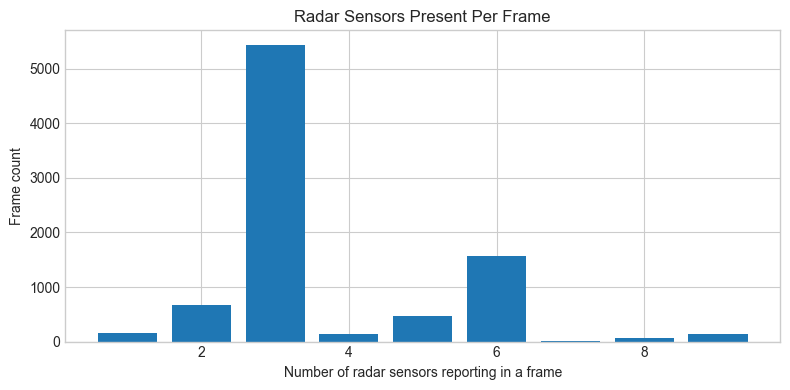

In [26]:
# Radar sensor participation per frame
radar_sensor_frame = radar_df.groupby("frame")["sensor_id"].nunique().rename("radar_sensor_count").reset_index()
sensor_count_dist = (
    radar_sensor_frame["radar_sensor_count"]
    .value_counts()
    .sort_index()
    .rename_axis("sensors_in_frame")
    .reset_index(name="frame_count")
)

display(sensor_count_dist)

plt.figure(figsize=(8, 4))
plt.bar(sensor_count_dist["sensors_in_frame"], sensor_count_dist["frame_count"])
plt.title("Radar Sensors Present Per Frame")
plt.xlabel("Number of radar sensors reporting in a frame")
plt.ylabel("Frame count")
plt.tight_layout()
plt.show()

Camera timestamp delta summary (seconds):
{
  "min": 0.007904000000053202,
  "median": 0.1450800000000072,
  "mean": 0.28330935087719294,
  "max": 61.97641900000008
}

Radar unique timestamp delta summary (seconds):
{
  "min": 0.006924999999910142,
  "median": 0.010014000000182932,
  "mean": 0.022578875101004252,
  "max": 59.74518699999999
}


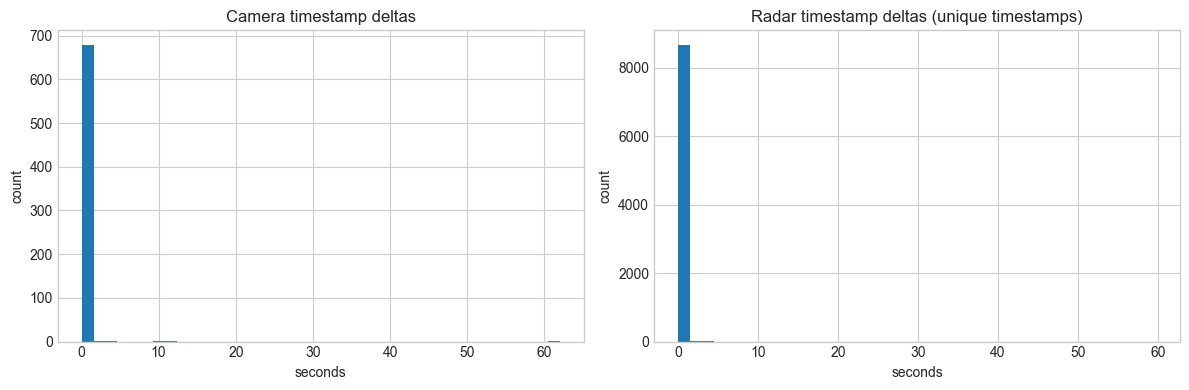

In [27]:
# Timestamp gap analysis
camera_ts = np.sort(camera_num["timestamp"].dropna().to_numpy())
radar_ts = np.sort(radar_num["timestamp"].dropna().unique())

camera_dt = np.diff(camera_ts) if len(camera_ts) > 1 else np.array([])
radar_dt = np.diff(radar_ts) if len(radar_ts) > 1 else np.array([])

def gap_summary(arr: np.ndarray) -> dict:
    if arr.size == 0:
        return {"min": None, "median": None, "mean": None, "max": None}
    return {
        "min": float(np.min(arr)),
        "median": float(np.median(arr)),
        "mean": float(np.mean(arr)),
        "max": float(np.max(arr)),
    }

print("Camera timestamp delta summary (seconds):")
print(json.dumps(gap_summary(camera_dt), indent=2))
print("\nRadar unique timestamp delta summary (seconds):")
print(json.dumps(gap_summary(radar_dt), indent=2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(camera_dt, bins=40)
axes[0].set_title("Camera timestamp deltas")
axes[0].set_xlabel("seconds")
axes[0].set_ylabel("count")

axes[1].hist(radar_dt, bins=40)
axes[1].set_title("Radar timestamp deltas (unique timestamps)")
axes[1].set_xlabel("seconds")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

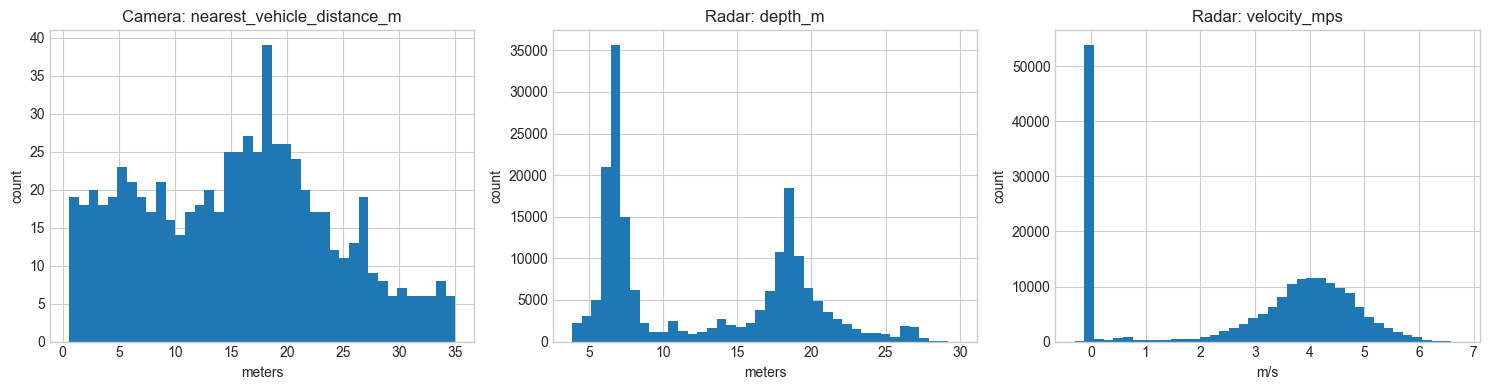

In [28]:
# Distribution plots for key measurements
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(camera_num["nearest_vehicle_distance_m"].dropna(), bins=40)
axes[0].set_title("Camera: nearest_vehicle_distance_m")
axes[0].set_xlabel("meters")

axes[1].hist(radar_num["depth_m"].dropna(), bins=40)
axes[1].set_title("Radar: depth_m")
axes[1].set_xlabel("meters")

axes[2].hist(radar_num["velocity_mps"].dropna(), bins=40)
axes[2].set_title("Radar: velocity_mps")
axes[2].set_xlabel("m/s")

for ax in axes:
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

In [29]:
# Optional: save a compact exploration report as JSON.
report = {
    "dataset_dir": str(DATASET_DIR),
    "camera_rows": int(len(camera_df)),
    "radar_rows": int(len(radar_df)),
    "camera_unique_frames": int(len(camera_frames)),
    "radar_unique_frames": int(len(radar_frames)),
    "common_frames": int(len(common_frames)),
    "camera_only_frames": int(len(camera_only_frames)),
    "radar_only_frames": int(len(radar_only_frames)),
    "camera_csv_without_png": int(len(csv_without_png)),
    "png_without_camera_csv": int(len(png_without_csv)),
    "camera_timestamp_delta_sec": gap_summary(camera_dt),
    "radar_unique_timestamp_delta_sec": gap_summary(radar_dt),
}

report_path = DATASET_DIR / "exploration_report.json"
report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")
print("Saved:", report_path)

Saved: C:\Users\Colin\Downloads\CARLA_Latest\Scripts\DatasetCreation\sensor_capture_20260325_183350\exploration_report.json


In [30]:
# Build a camera-radar paired dataset using nearest timestamp matching.
# You can tune tolerance based on your desired synchronization strictness.

TOLERANCE_MS = 30  # try 20, 30, or 50
TOLERANCE_SEC = TOLERANCE_MS / 1000.0

# Aggregate radar detections to one row per radar frame/timestamp.
radar_frame_level = (
    radar_num
    .groupby(["frame", "timestamp"], as_index=False)
    .agg(
        radar_detection_count=("detection_index", "count"),
        radar_depth_m_mean=("depth_m", "mean"),
        radar_depth_m_min=("depth_m", "min"),
        radar_depth_m_max=("depth_m", "max"),
        radar_velocity_mps_mean=("velocity_mps", "mean"),
        radar_velocity_mps_min=("velocity_mps", "min"),
        radar_velocity_mps_max=("velocity_mps", "max"),
        radar_matched_vehicle_dist_m_mean=("matched_vehicle_distance_m", "mean"),
        radar_unique_sensor_count=("sensor_id", "nunique"),
    )
    .sort_values("timestamp")
    .reset_index(drop=True)
)

camera_sorted = camera_num.sort_values("timestamp").reset_index(drop=True).copy()

paired = pd.merge_asof(
    camera_sorted,
    radar_frame_level,
    on="timestamp",
    direction="nearest",
    tolerance=TOLERANCE_SEC,
    suffixes=("_camera", "_radar"),
)

# Keep the original camera timestamp and compute exact join error.
paired = paired.rename(columns={"timestamp": "camera_timestamp"})

# Recover radar timestamp via second merge for transparent error accounting.
radar_ts_lookup = radar_frame_level[["frame", "timestamp"]].rename(
    columns={"frame": "frame_radar", "timestamp": "radar_timestamp"}
)
paired = paired.merge(radar_ts_lookup, on="frame_radar", how="left")

# Rerun-safe handling in case a prior run left radar_timestamp columns around.
if "radar_timestamp_y" in paired.columns:
    paired["radar_timestamp"] = paired["radar_timestamp_y"]
    drop_cols = [c for c in ["radar_timestamp_x", "radar_timestamp_y"] if c in paired.columns]
    paired = paired.drop(columns=drop_cols)
elif "radar_timestamp" not in paired.columns and "radar_timestamp_x" in paired.columns:
    paired = paired.rename(columns={"radar_timestamp_x": "radar_timestamp"})

paired["abs_time_delta_ms"] = (paired["camera_timestamp"] - paired["radar_timestamp"]).abs() * 1000.0

matched = paired[paired["frame_radar"].notna()].copy()
unmatched = paired[paired["frame_radar"].isna()].copy()

match_rate = (len(matched) / len(paired) * 100.0) if len(paired) else 0.0

print(f"Tolerance: {TOLERANCE_MS} ms")
print(f"Camera rows: {len(paired)}")
print(f"Matched rows: {len(matched)} ({match_rate:.2f}%)")
print(f"Unmatched rows: {len(unmatched)}")

if len(matched):
    print("Matched abs_time_delta_ms summary:")
    print(matched["abs_time_delta_ms"].describe(percentiles=[0.25, 0.5, 0.75]).round(3))

match_report = pd.DataFrame(
    [
        {"metric": "tolerance_ms", "value": TOLERANCE_MS},
        {"metric": "camera_rows", "value": len(paired)},
        {"metric": "matched_rows", "value": len(matched)},
        {"metric": "unmatched_rows", "value": len(unmatched)},
        {"metric": "match_rate_pct", "value": round(match_rate, 3)},
        {
            "metric": "matched_median_abs_time_delta_ms",
            "value": round(float(matched["abs_time_delta_ms"].median()), 3) if len(matched) else np.nan,
        },
    ]
)

display(match_report)
display(matched.head(5))

paired_csv = DATASET_DIR / f"camera_radar_paired_{TOLERANCE_MS}ms.csv"
matched_csv = DATASET_DIR / f"camera_radar_paired_matched_{TOLERANCE_MS}ms.csv"

paired.to_csv(paired_csv, index=False)
matched.to_csv(matched_csv, index=False)

print("Saved:")
print(" -", paired_csv)
print(" -", matched_csv)

Tolerance: 30 ms
Camera rows: 685
Matched rows: 534 (77.96%)
Unmatched rows: 151
Matched abs_time_delta_ms summary:
count    534.000
mean       0.102
std        1.428
min        0.000
25%        0.000
50%        0.000
75%        0.000
max       24.118
Name: abs_time_delta_ms, dtype: float64


,metric,value
0,tolerance_ms,30.000
1,camera_rows,685.000
2,matched_rows,534.000
3,unmatched_rows,151.000
4,match_rate_pct,77.956
5,matched_median_abs_time_delta_ms,0.000


,sensor_id,frame_camera,camera_timestamp,width,height,image_path,nearest_vehicle_id,nearest_vehicle_distance_m,nearby_vehicle_ids,frame_radar,...,radar_depth_m_mean,radar_depth_m_min,radar_depth_m_max,radar_velocity_mps_mean,radar_velocity_mps_min,radar_velocity_mps_max,radar_matched_vehicle_dist_m_mean,radar_unique_sensor_count,radar_timestamp,abs_time_delta_ms
0,75,259918,1543.280794,800,600,C:\Users\Colin\Downloads\CARLA_Latest\Scripts\...,80,34.975653,80,259918.0,...,18.502610,16.124918,19.245300,2.836089,-0.0,3.944328,2.181199,3.0,1543.280794,0.0
1,75,259919,1543.288698,800,600,C:\Users\Colin\Downloads\CARLA_Latest\Scripts\...,80,34.081441,80,259919.0,...,18.697466,14.850635,23.045637,1.860738,-0.0,3.729395,3.037332,3.0,1543.288698,0.0
2,75,259936,1543.420450,800,600,C:\Users\Colin\Downloads\CARLA_Latest\Scripts\...,80,33.352292,80,259936.0,...,17.692759,15.170607,19.558151,1.820261,-0.0,3.674357,3.792711,3.0,1543.420450,0.0
3,75,259953,1543.552291,800,600,C:\Users\Colin\Downloads\CARLA_Latest\Scripts\...,80,32.605348,80,259953.0,...,20.549104,17.135019,26.409042,1.681074,-0.0,3.487556,3.002891,3.0,1543.552291,0.0
4,75,259970,1543.699687,800,600,C:\Users\Colin\Downloads\CARLA_Latest\Scripts\...,80,31.928038,80,259970.0,...,20.899541,16.687723,26.356968,1.818444,-0.0,3.554298,3.493242,3.0,1543.699687,0.0


Saved:
 - C:\Users\Colin\Downloads\CARLA_Latest\Scripts\DatasetCreation\sensor_capture_20260325_183350\camera_radar_paired_30ms.csv
 - C:\Users\Colin\Downloads\CARLA_Latest\Scripts\DatasetCreation\sensor_capture_20260325_183350\camera_radar_paired_matched_30ms.csv


C:\Users\Colin\AppData\Local\Temp\ipykernel_594904\2026800231.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1])


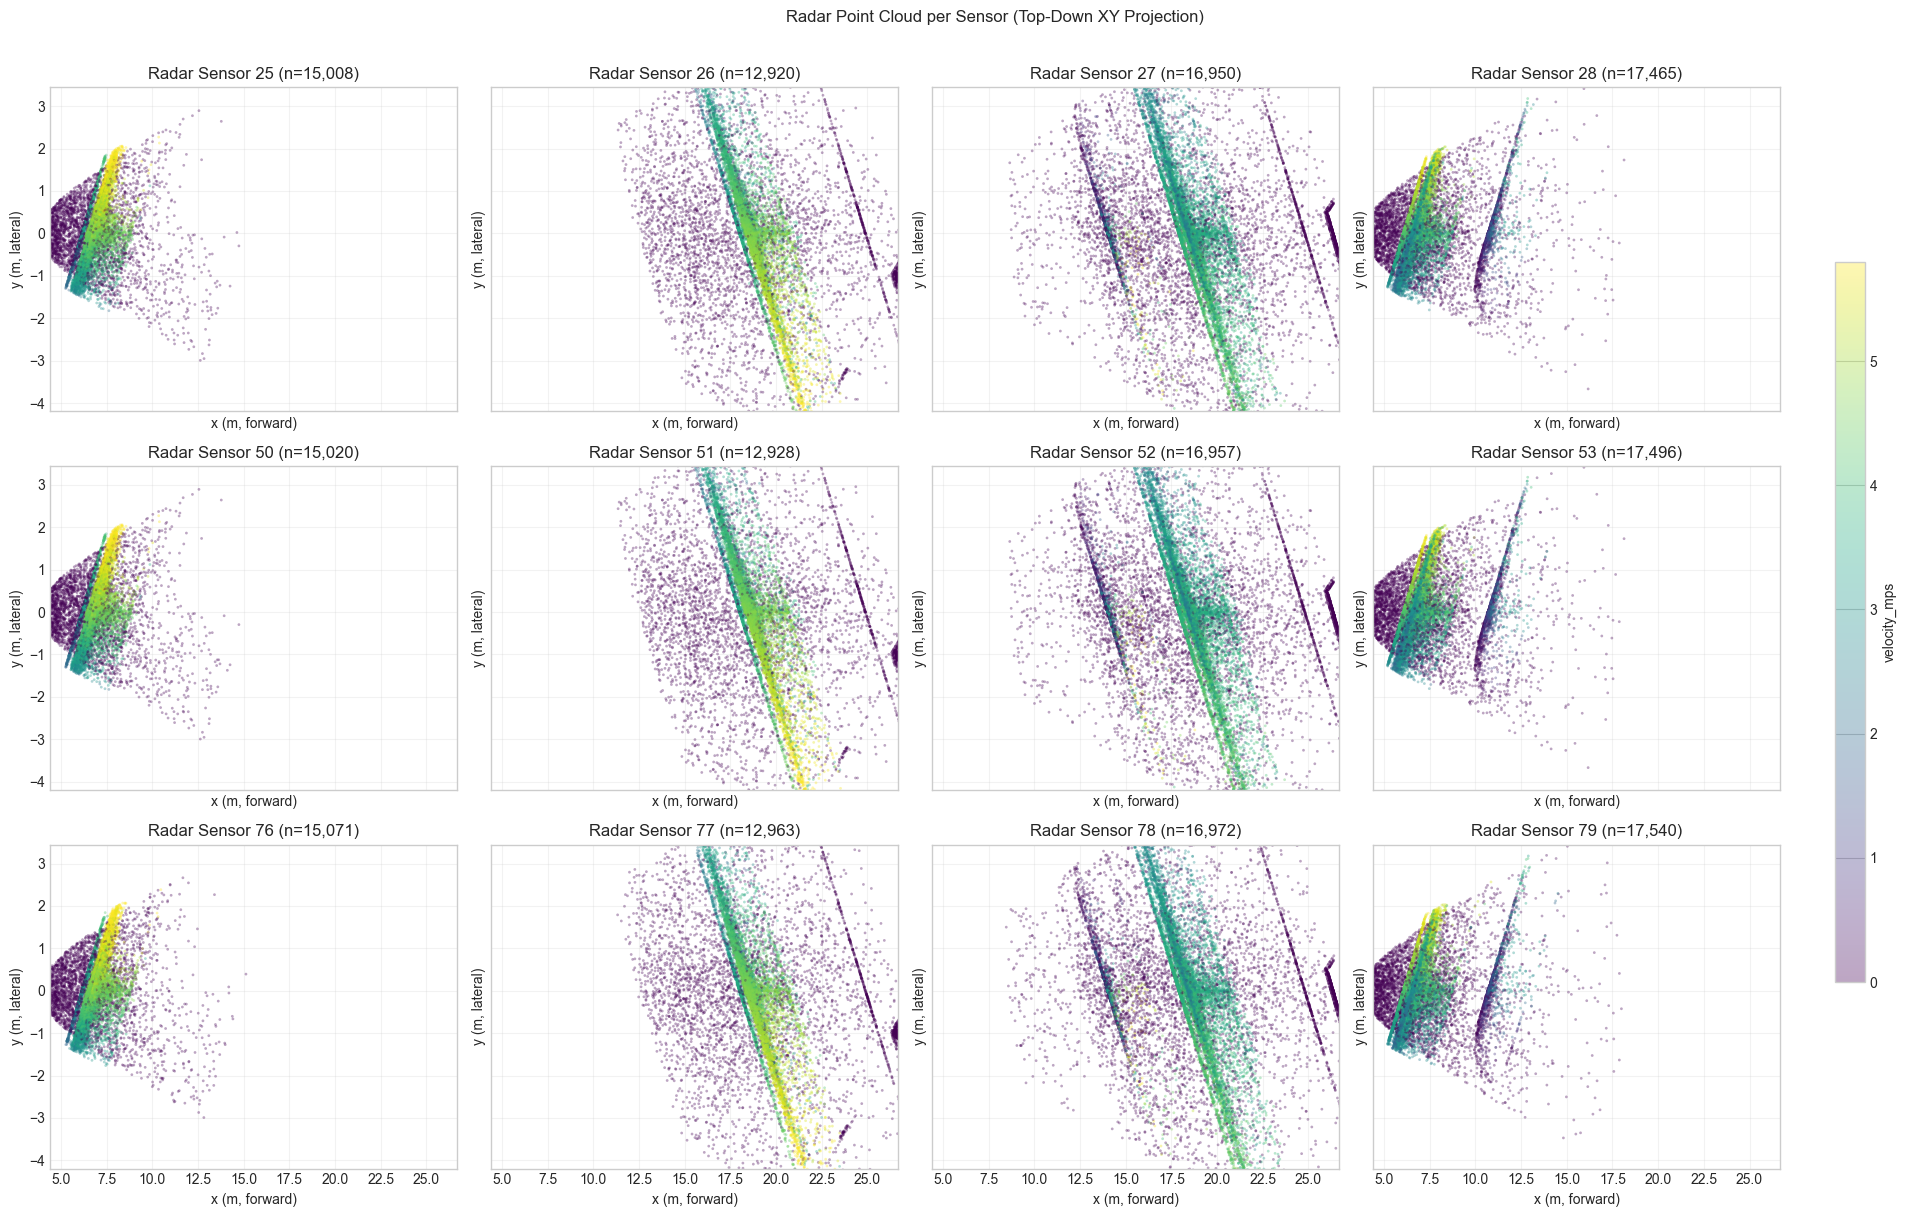

In [31]:
# Radar cloud per sensor (top-down projection)
# Uses all detections and plots one subplot per radar sensor.

# Ensure numeric types (safe if already converted earlier).
radar_plot = radar_num.copy()
for c in ["sensor_id", "depth_m", "azimuth_rad", "velocity_mps"]:
    radar_plot[c] = pd.to_numeric(radar_plot[c], errors="coerce")
radar_plot = radar_plot.dropna(subset=["sensor_id", "depth_m", "azimuth_rad", "velocity_mps"]).copy()
radar_plot["sensor_id"] = radar_plot["sensor_id"].astype(int)

# Convert polar radar measurements to XY in sensor-local top-down plane.
# x: forward distance, y: lateral distance.
radar_plot["x_m"] = radar_plot["depth_m"] * np.cos(radar_plot["azimuth_rad"])
radar_plot["y_m"] = radar_plot["depth_m"] * np.sin(radar_plot["azimuth_rad"])

sensor_ids = sorted(radar_plot["sensor_id"].unique())
if len(sensor_ids) == 0:
    raise ValueError("No radar detections available to plot.")

n = len(sensor_ids)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

# Global limits for comparable panels.
x_min, x_max = radar_plot["x_m"].quantile([0.01, 0.99])
y_min, y_max = radar_plot["y_m"].quantile([0.01, 0.99])

vmin, vmax = radar_plot["velocity_mps"].quantile([0.01, 0.99])

for i, sid in enumerate(sensor_ids):
    ax = axes[i]
    df_s = radar_plot[radar_plot["sensor_id"] == sid]

    sc = ax.scatter(
        df_s["x_m"],
        df_s["y_m"],
        c=df_s["velocity_mps"],
        s=4,
        alpha=0.35,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        linewidths=0,
    )
    ax.set_title(f"Radar Sensor {sid} (n={len(df_s):,})")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("x (m, forward)")
    ax.set_ylabel("y (m, lateral)")
    ax.grid(True, alpha=0.25)

# Hide unused axes.
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# Reserve right margin and place colorbar outside subplot grid.
fig.subplots_adjust(right=0.90)
cax = fig.add_axes([0.92, 0.20, 0.015, 0.60])
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label("velocity_mps")

fig.suptitle("Radar Point Cloud per Sensor (Top-Down XY Projection)", y=1.01)
plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.show()

Plotting 10 frame(s): [np.int64(259740), np.int64(259741), np.int64(259742), np.int64(259743), np.int64(259744), np.int64(259745), np.int64(259746), np.int64(259747), np.int64(259748), np.int64(259749)]


C:\Users\Colin\AppData\Local\Temp\ipykernel_594904\3590111079.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1])


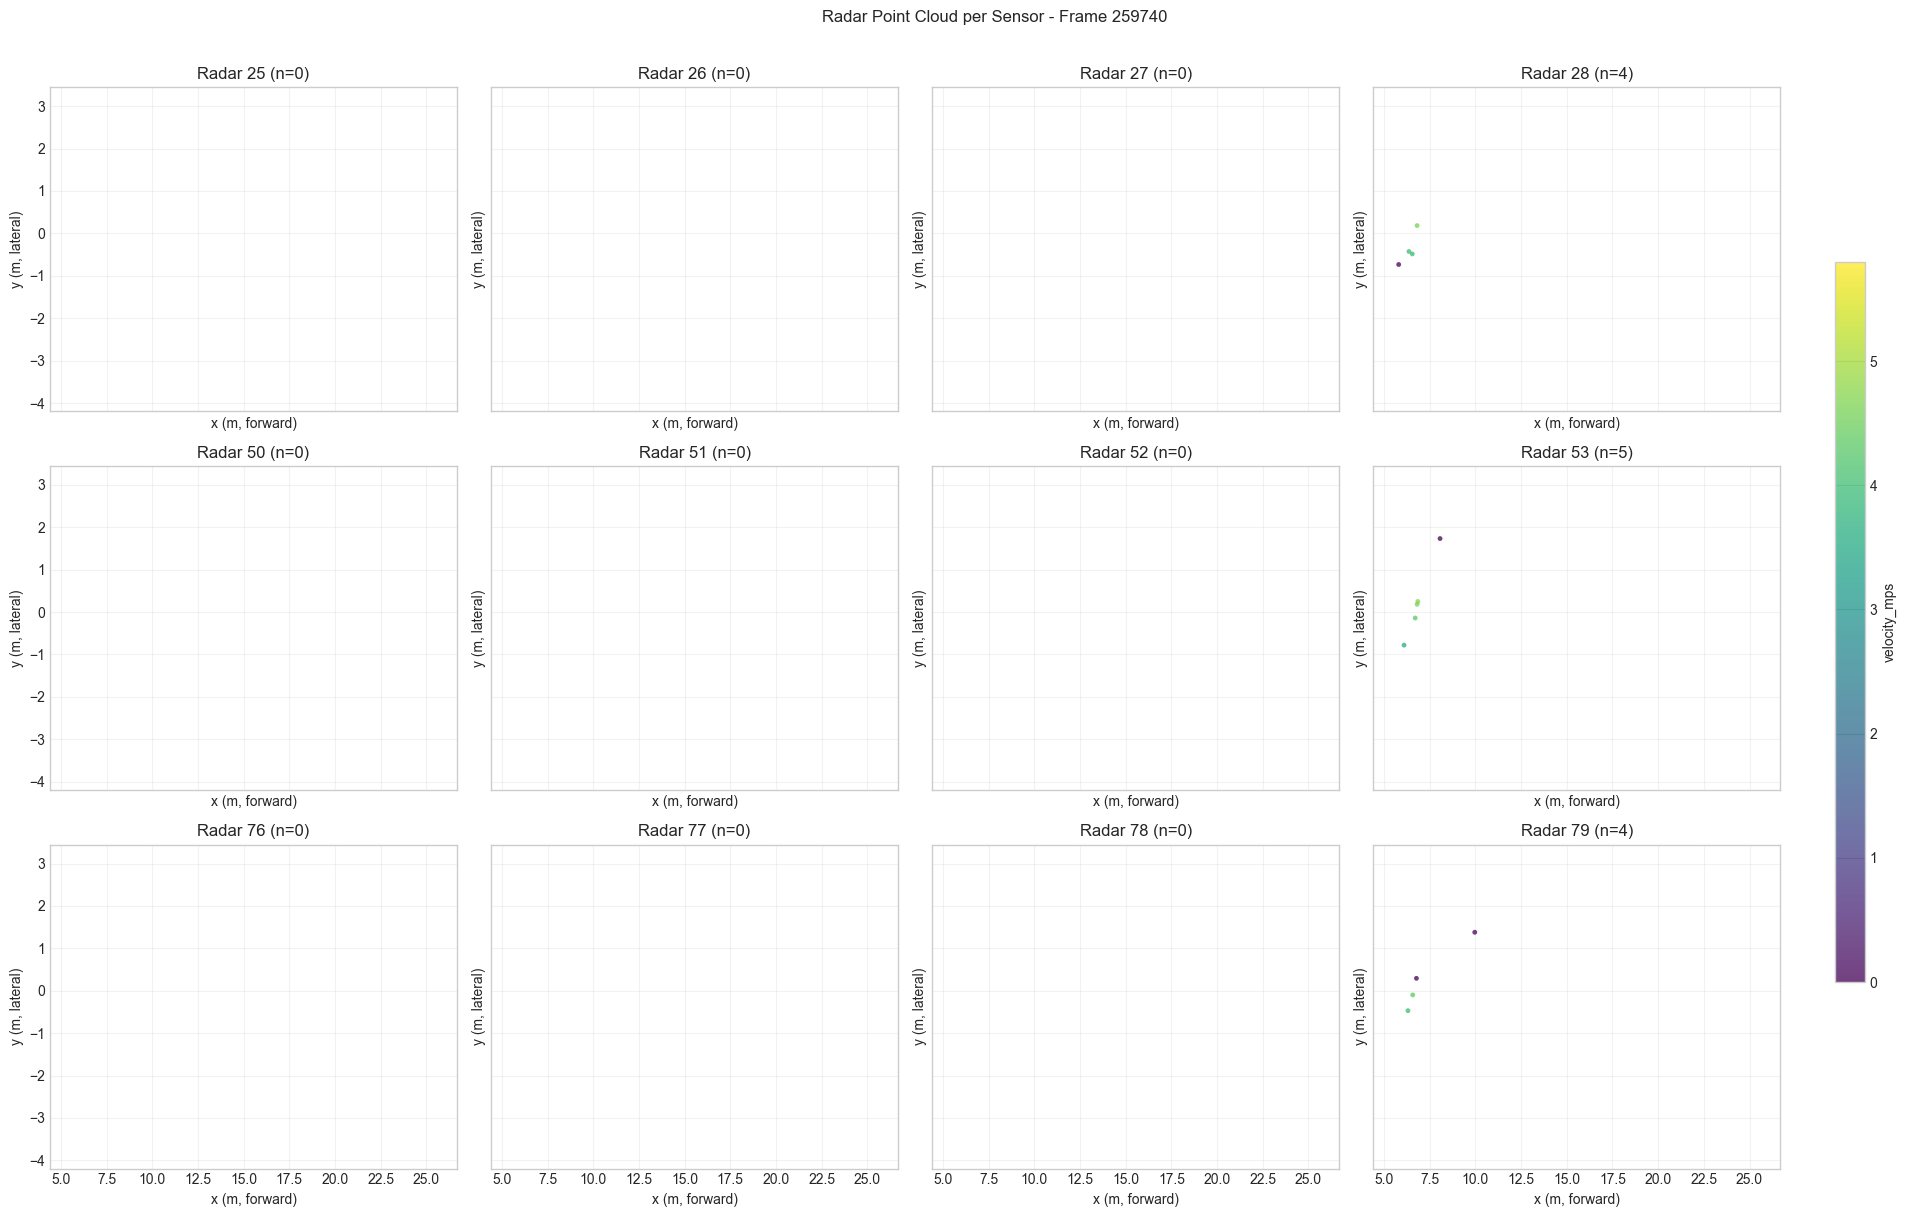

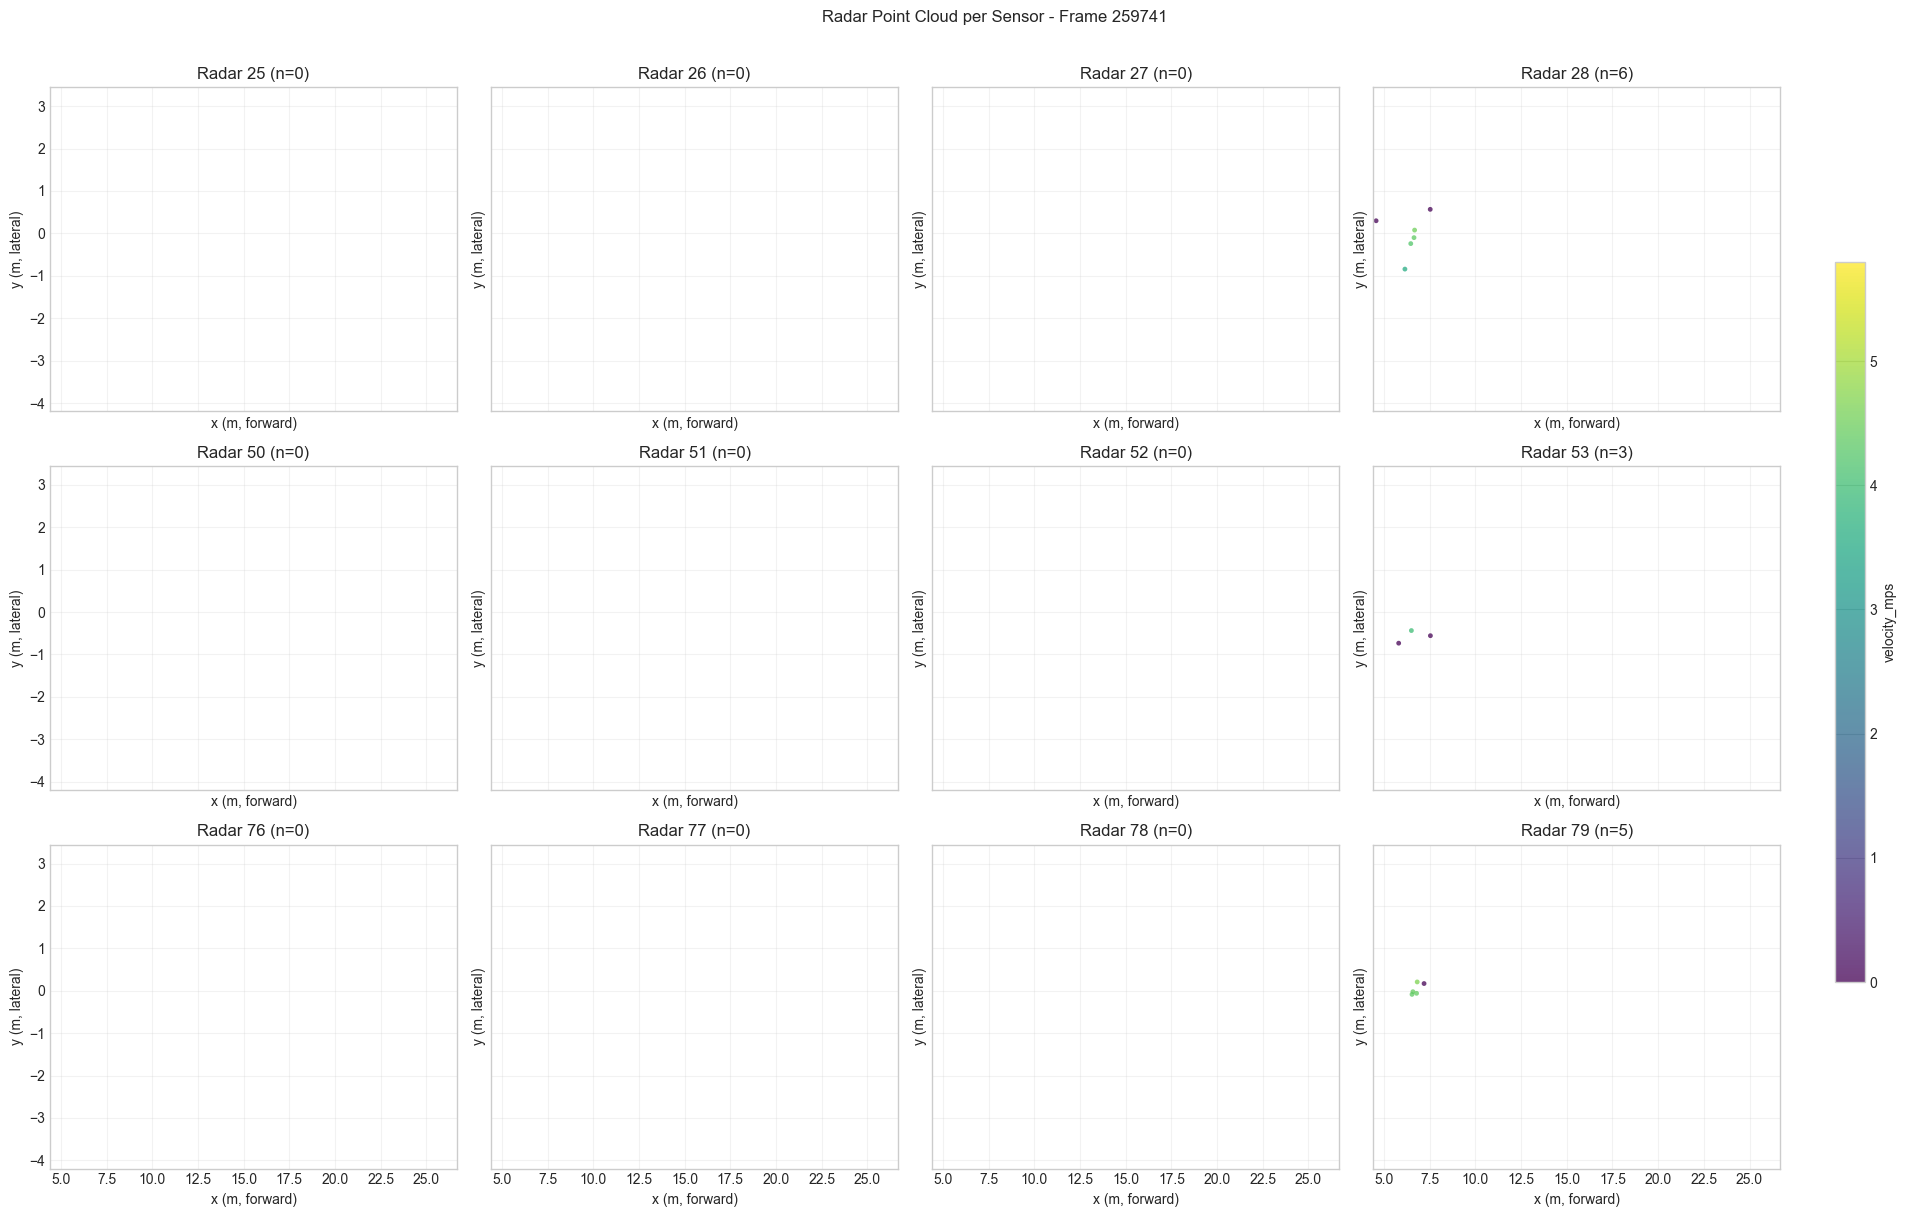

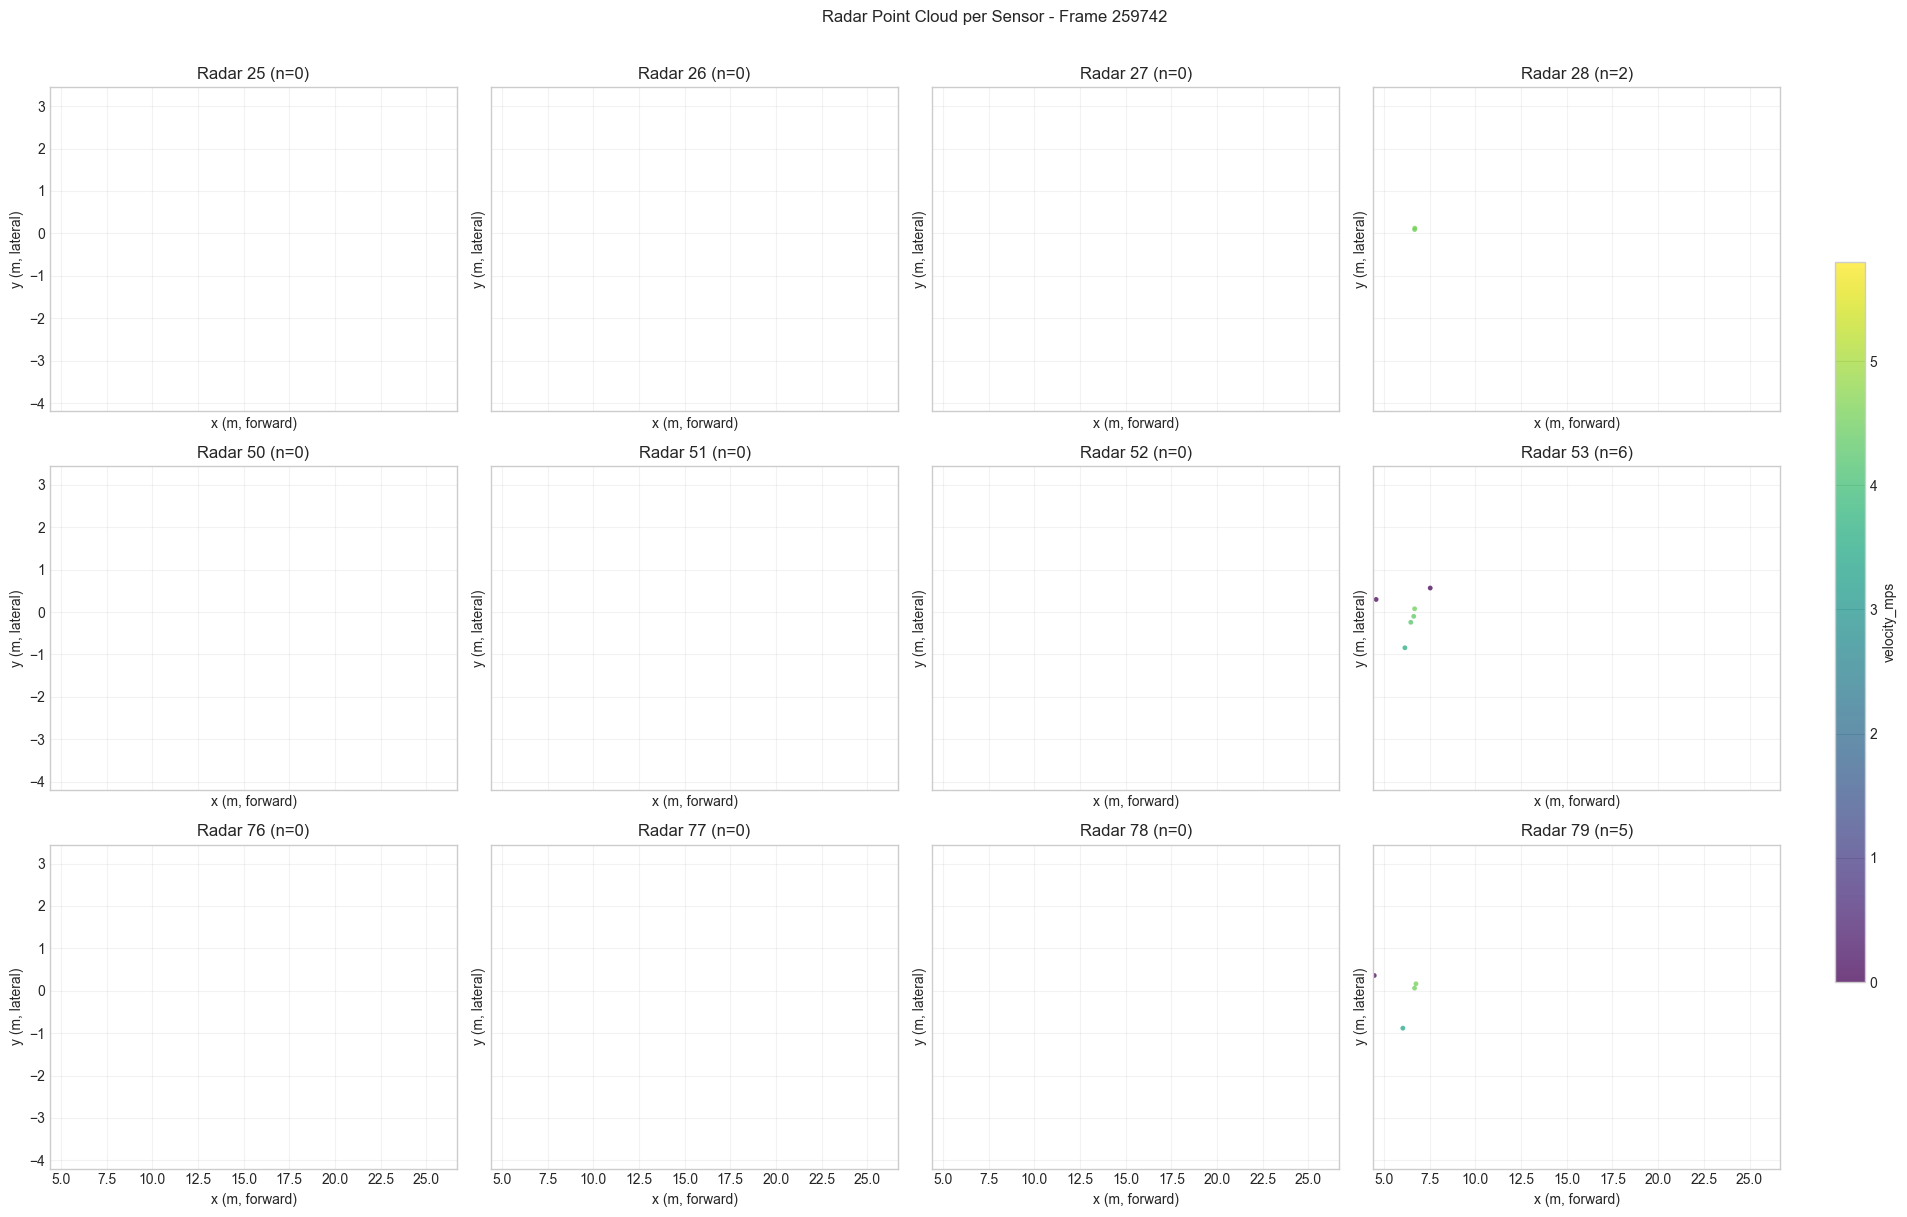

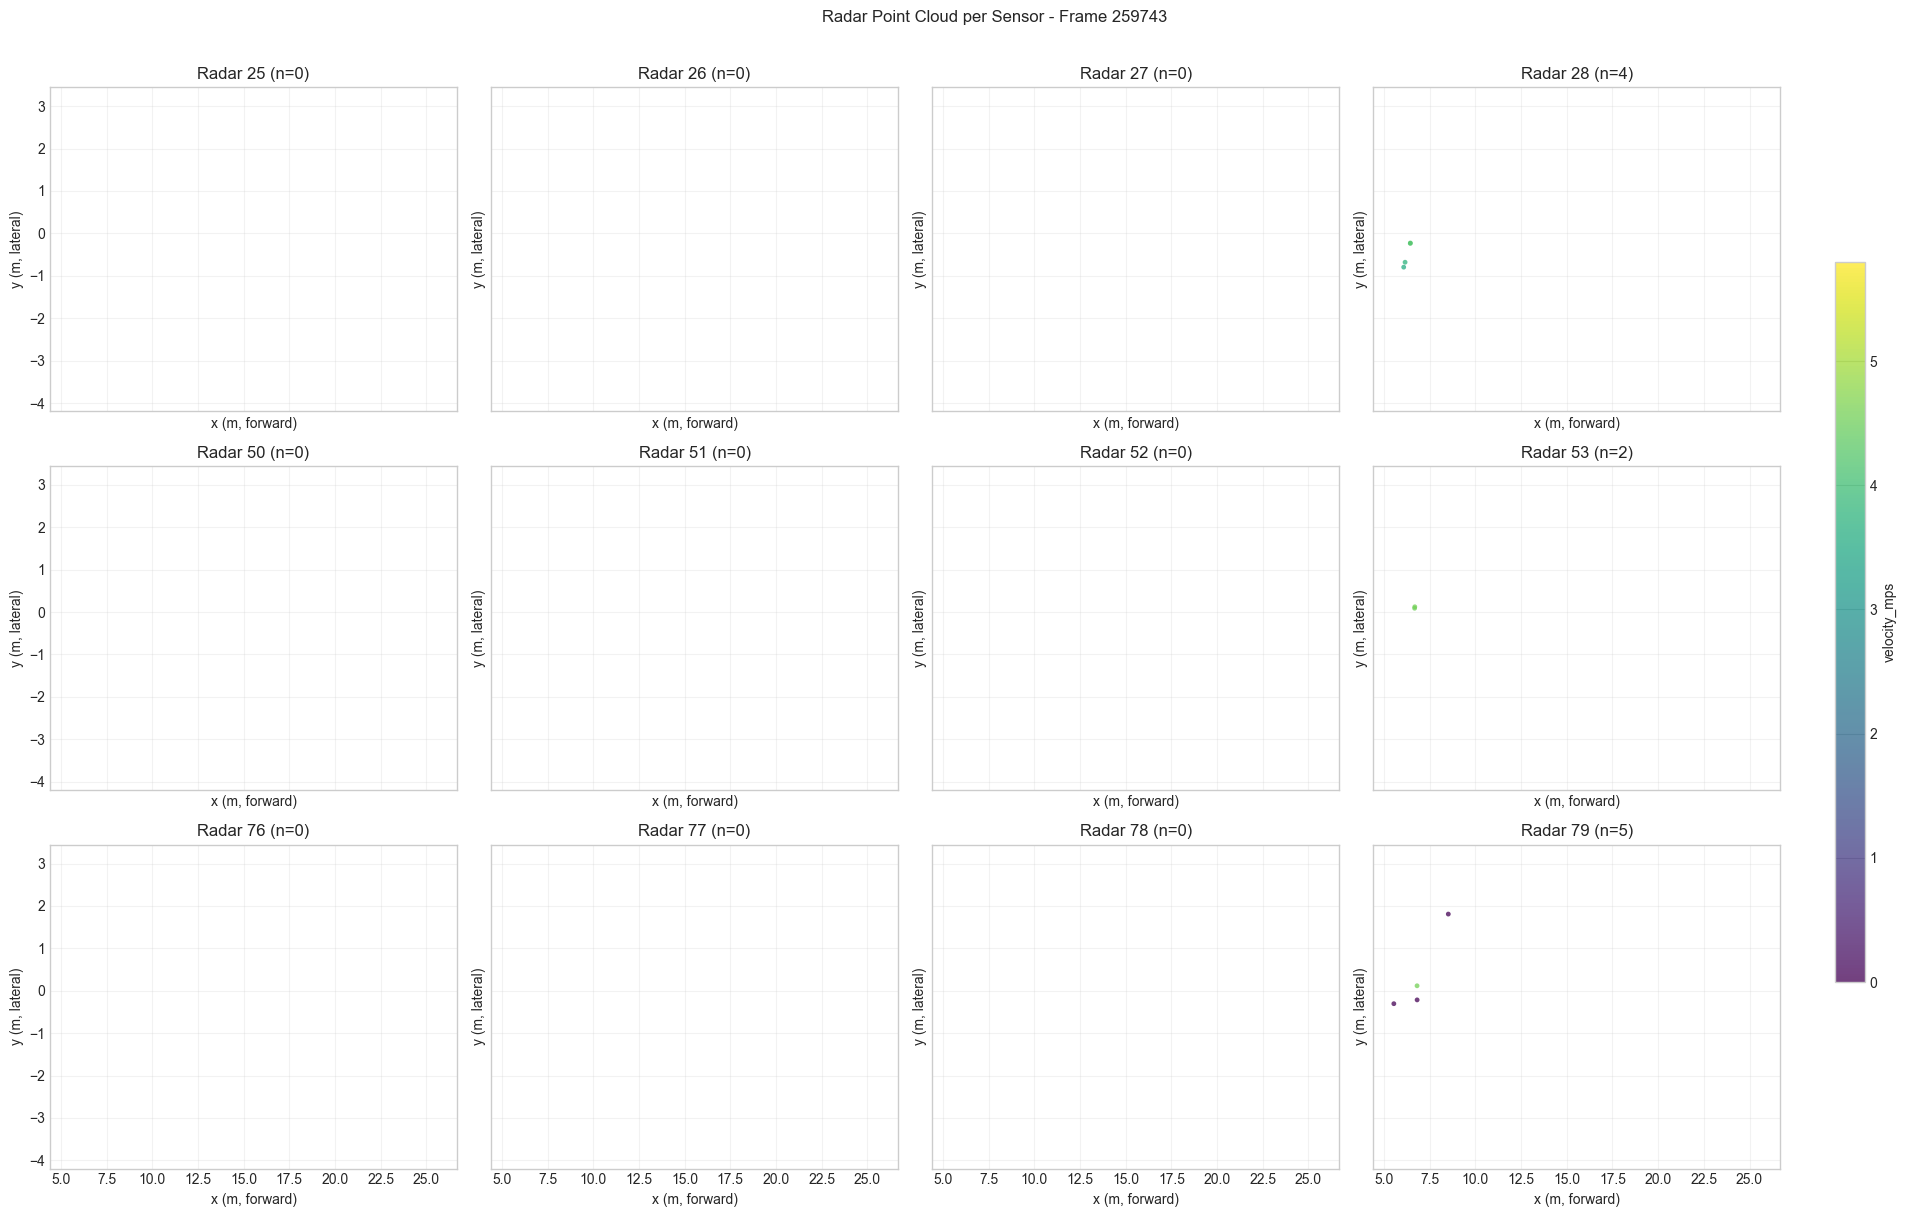

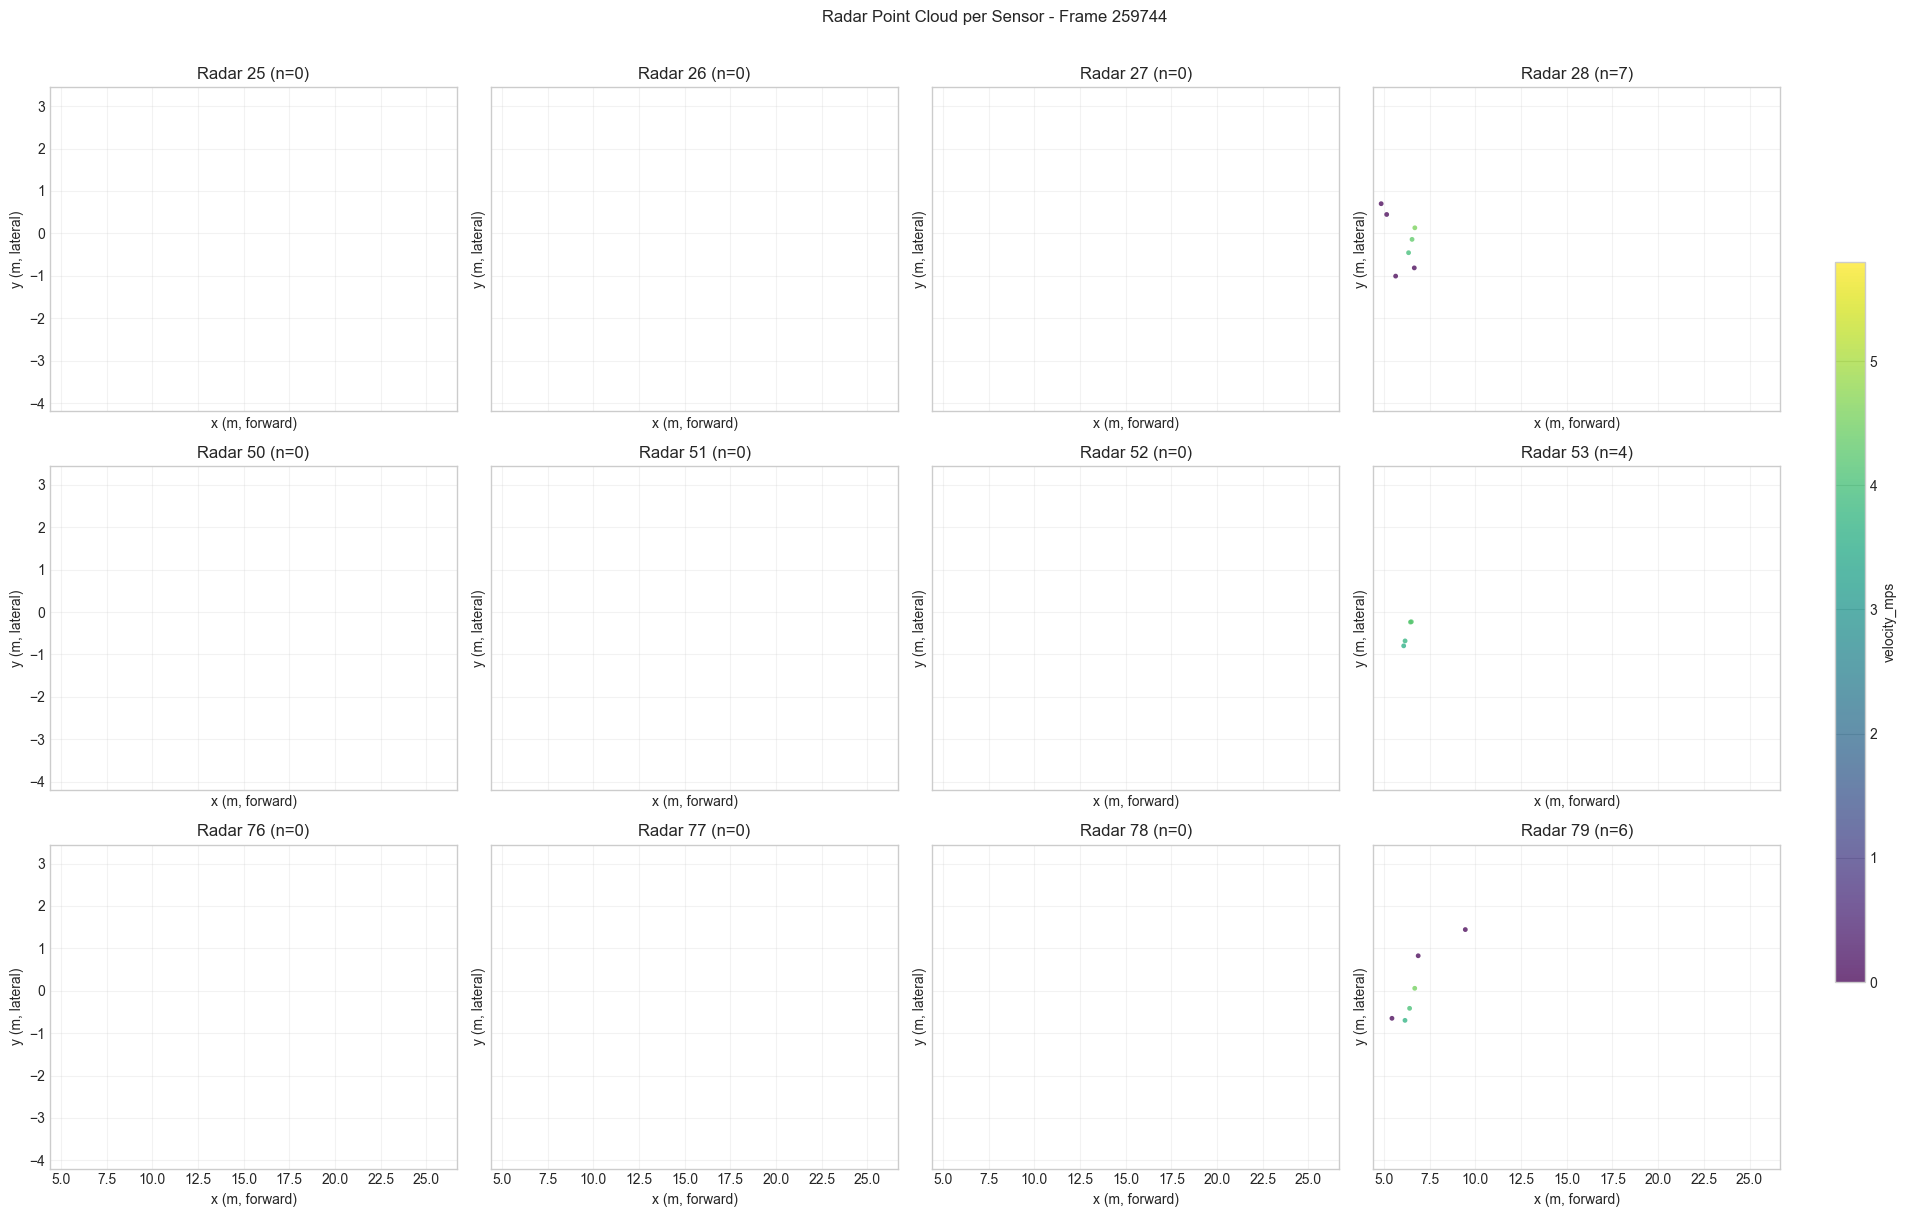

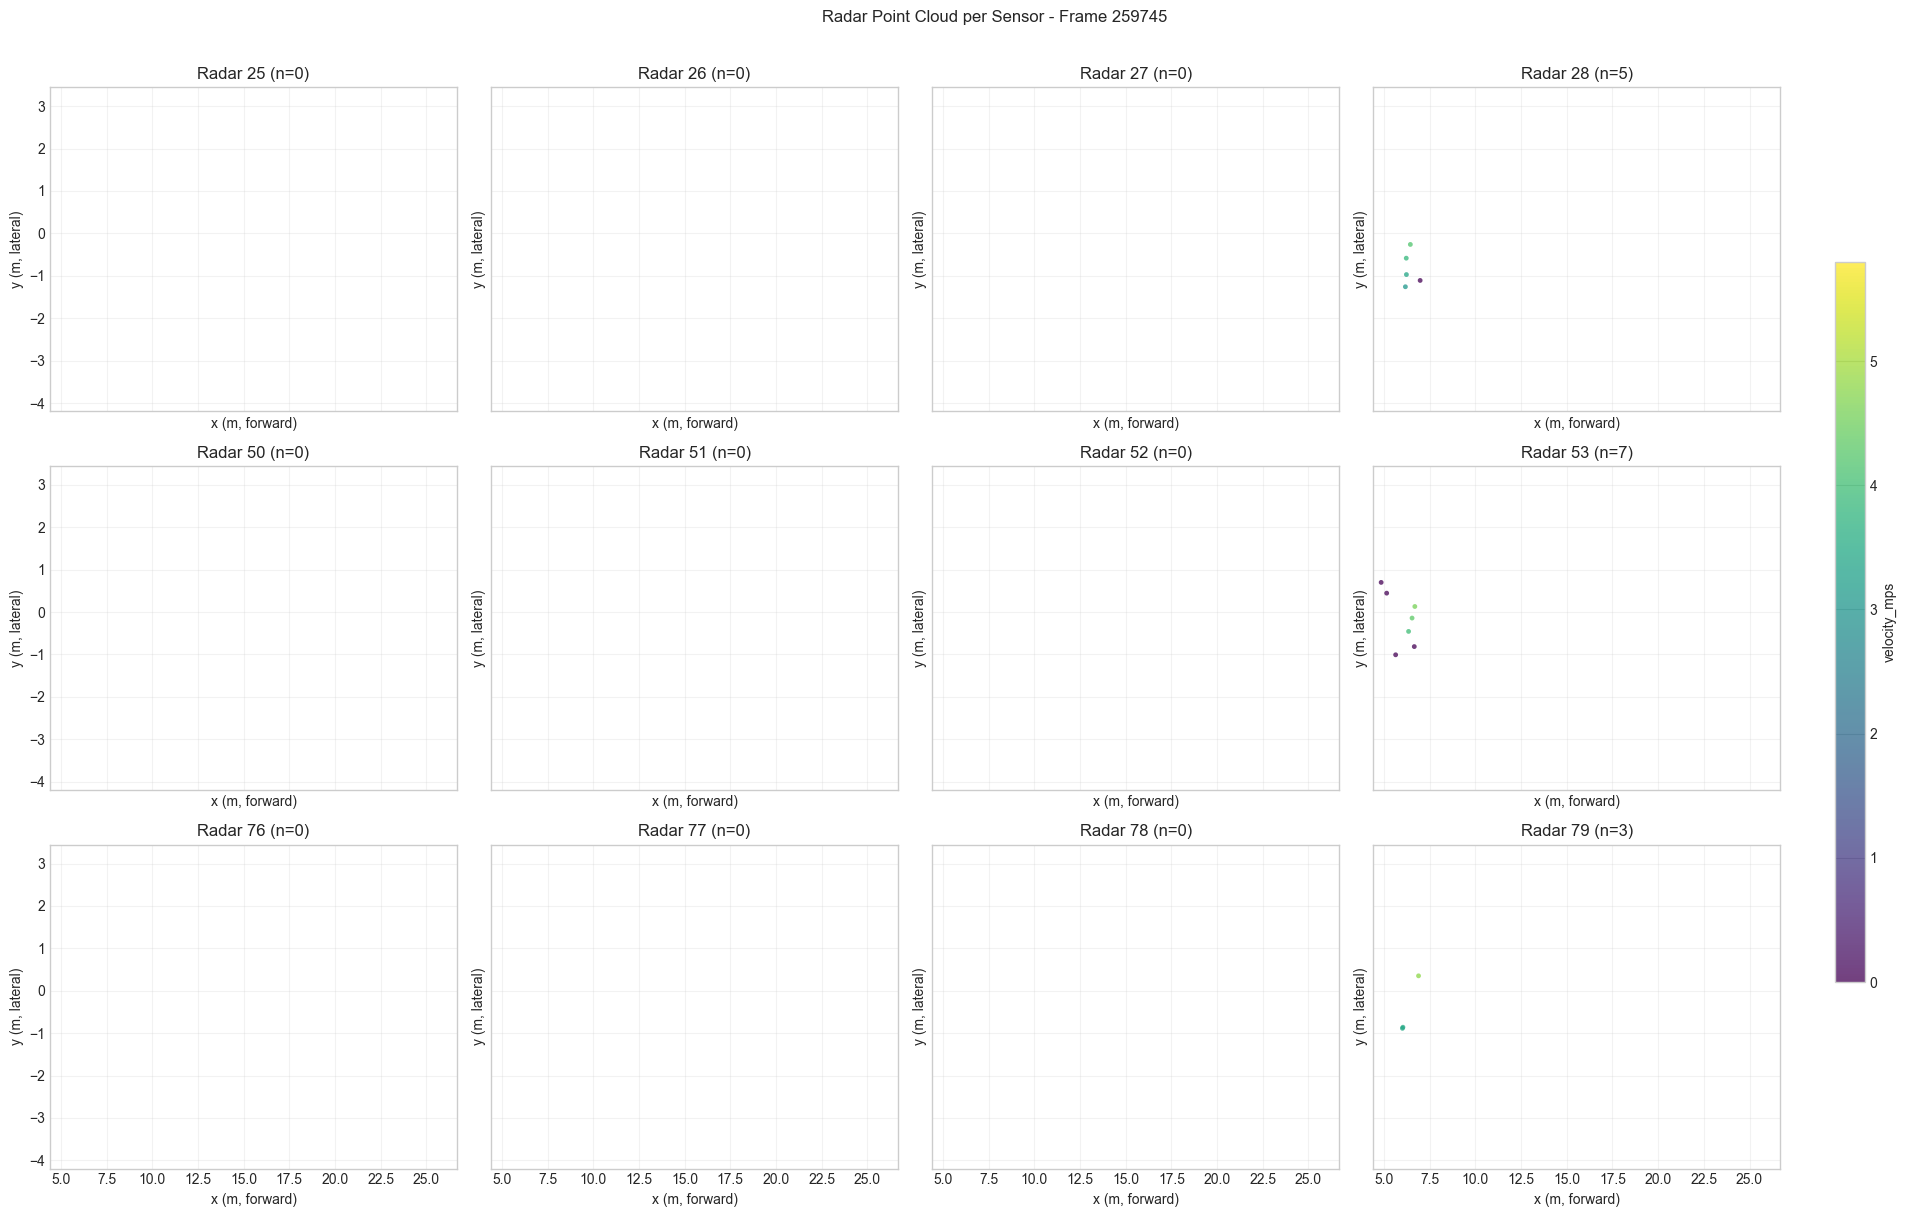

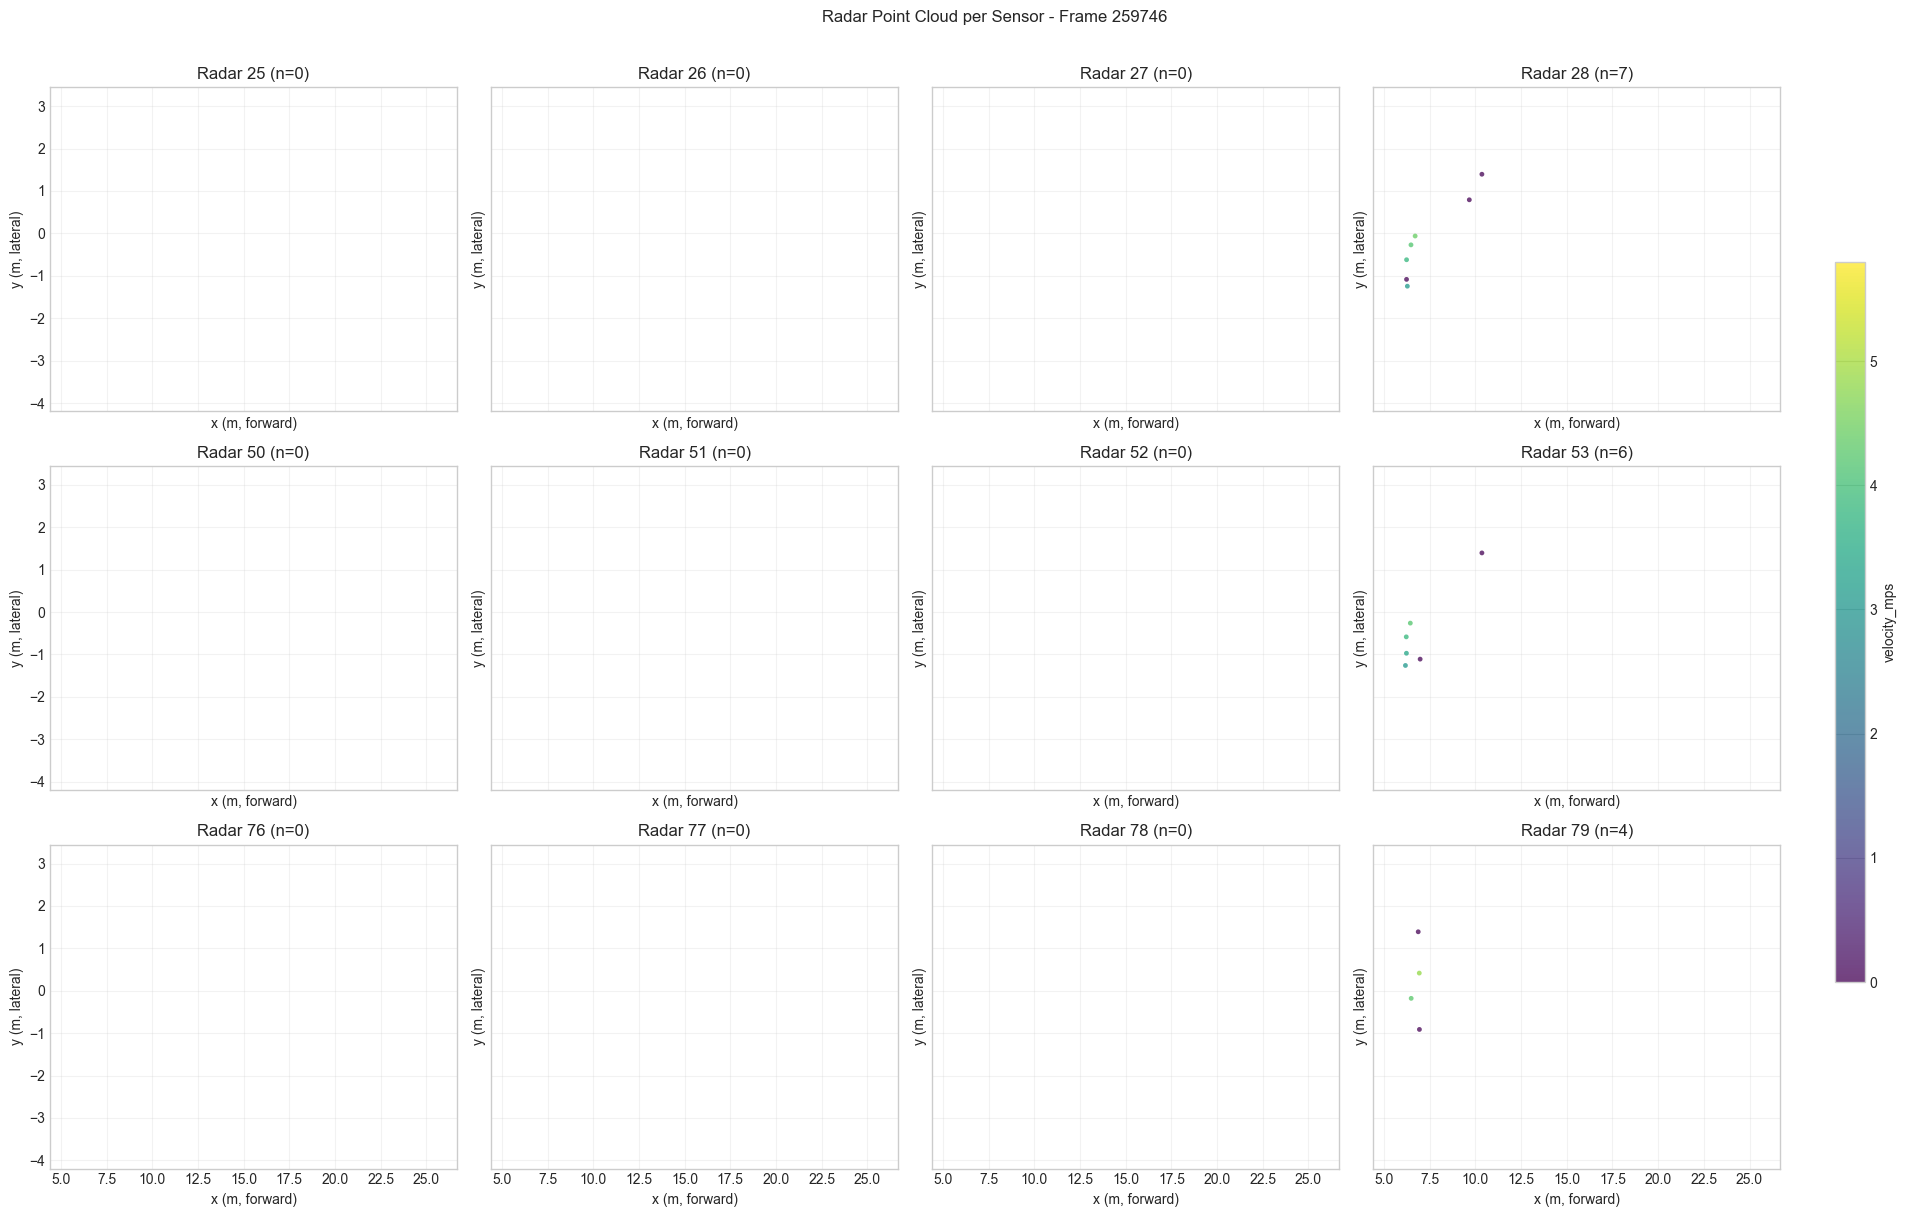

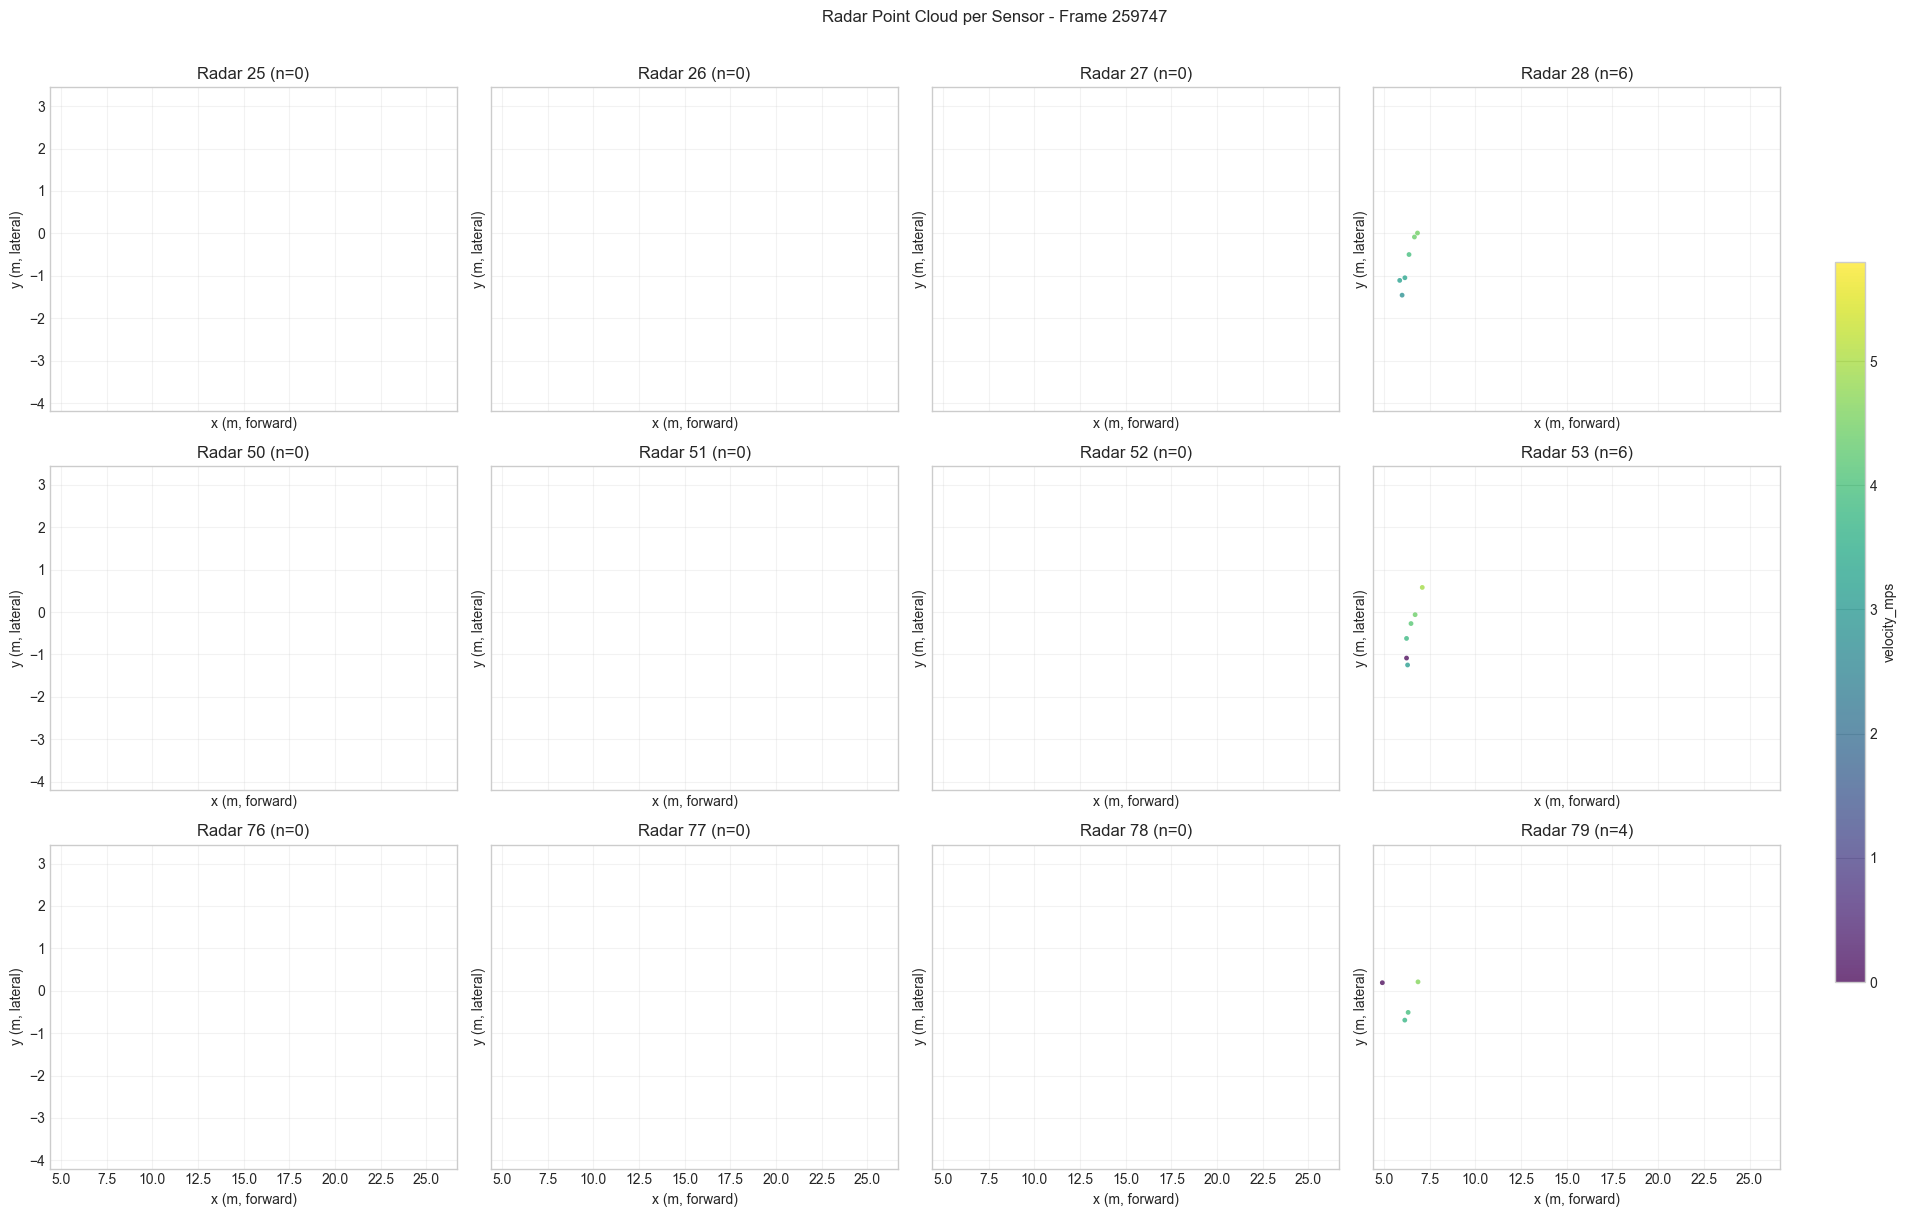

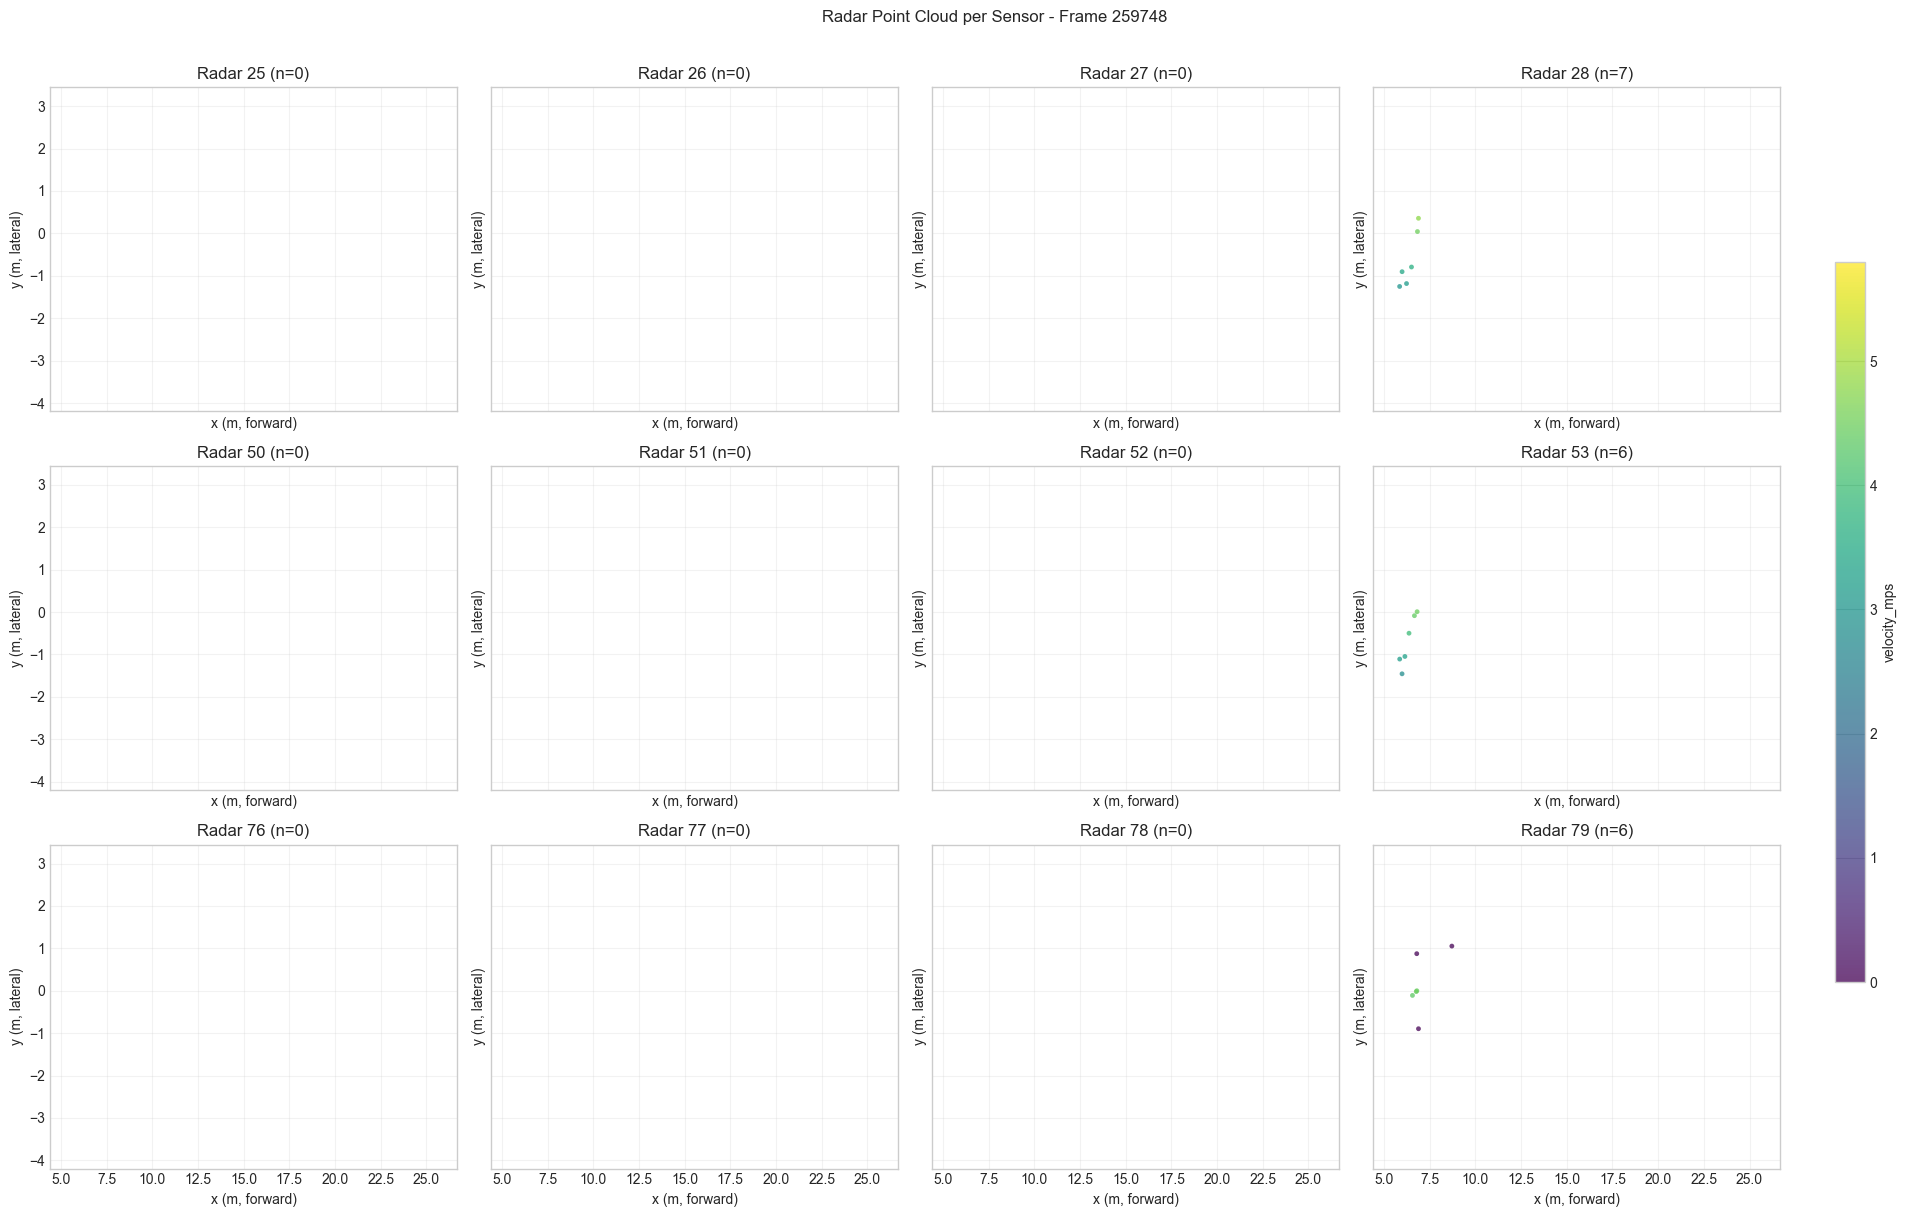

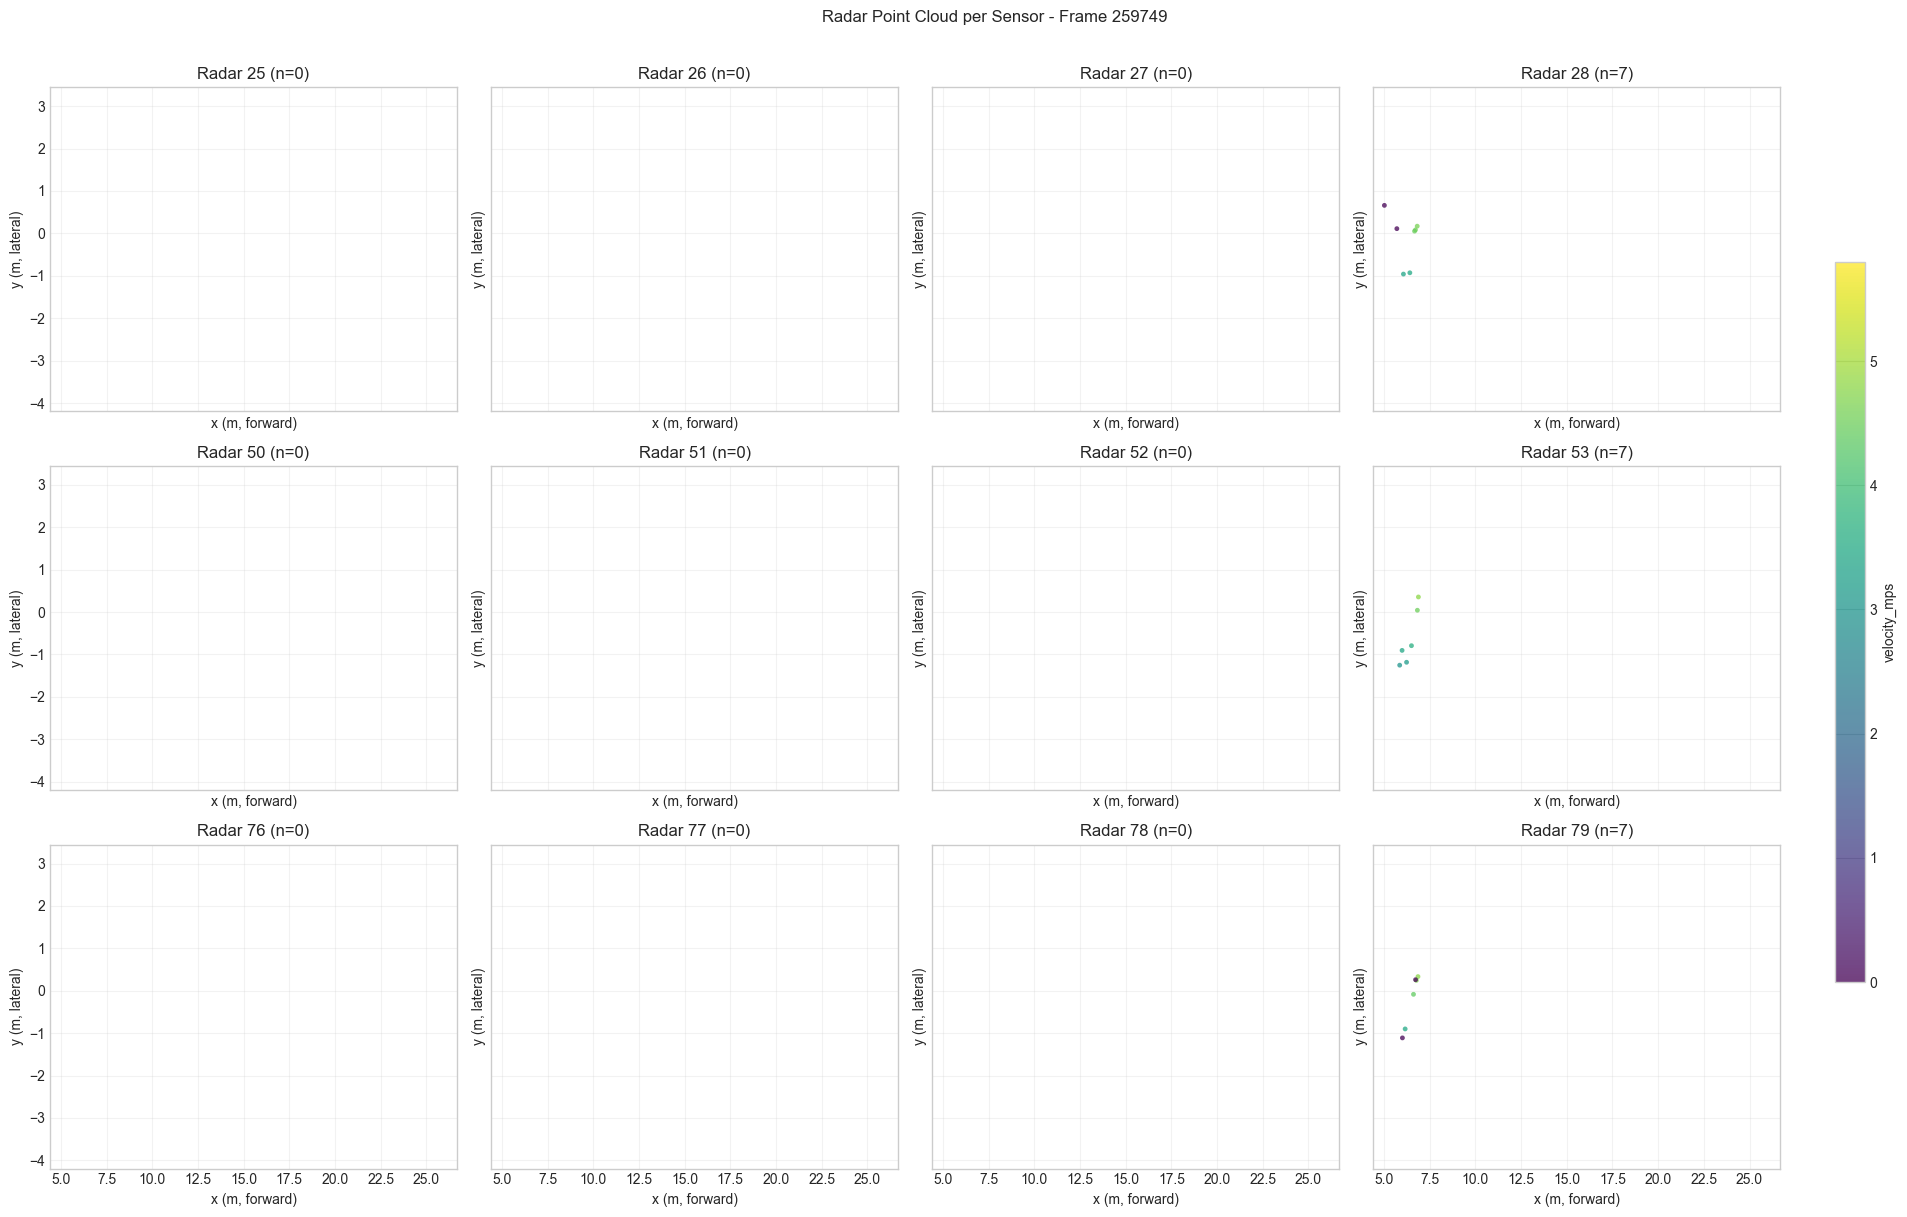

In [32]:
# Radar cloud per sensor, frame-by-frame (first N frames)
# This shows temporal snapshots instead of aggregating all frames.

MAX_FRAMES = 10

radar_frame_plot = radar_num.copy()
for c in ["sensor_id", "frame", "depth_m", "azimuth_rad", "velocity_mps"]:
    radar_frame_plot[c] = pd.to_numeric(radar_frame_plot[c], errors="coerce")

radar_frame_plot = radar_frame_plot.dropna(
    subset=["sensor_id", "frame", "depth_m", "azimuth_rad", "velocity_mps"]
).copy()
radar_frame_plot["sensor_id"] = radar_frame_plot["sensor_id"].astype(int)
radar_frame_plot["frame"] = radar_frame_plot["frame"].astype(int)

# Convert polar measurements to top-down XY in sensor-local coordinates.
radar_frame_plot["x_m"] = radar_frame_plot["depth_m"] * np.cos(radar_frame_plot["azimuth_rad"])
radar_frame_plot["y_m"] = radar_frame_plot["depth_m"] * np.sin(radar_frame_plot["azimuth_rad"])

sensor_ids = sorted(radar_frame_plot["sensor_id"].unique())
frame_ids = sorted(radar_frame_plot["frame"].unique())[:MAX_FRAMES]

if len(frame_ids) == 0:
    raise ValueError("No radar frames available to plot.")

print(f"Plotting {len(frame_ids)} frame(s): {frame_ids}")

# Global scales for consistent visual comparison across frames.
x_min, x_max = radar_frame_plot["x_m"].quantile([0.01, 0.99])
y_min, y_max = radar_frame_plot["y_m"].quantile([0.01, 0.99])
vmin, vmax = radar_frame_plot["velocity_mps"].quantile([0.01, 0.99])

ncols = 4

for frame_id in frame_ids:
    df_f = radar_frame_plot[radar_frame_plot["frame"] == frame_id]
    n = len(sensor_ids)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5 * ncols, 4 * nrows),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for i, sid in enumerate(sensor_ids):
        ax = axes[i]
        df_s = df_f[df_f["sensor_id"] == sid]

        if len(df_s) > 0:
            sc = ax.scatter(
                df_s["x_m"],
                df_s["y_m"],
                c=df_s["velocity_mps"],
                s=12,
                alpha=0.75,
                cmap="viridis",
                vmin=vmin,
                vmax=vmax,
                linewidths=0,
            )
        else:
            # Keep empty panel for missing sensor in this frame.
            ax.scatter([], [])

        ax.set_title(f"Radar {sid} (n={len(df_s)})")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xlabel("x (m, forward)")
        ax.set_ylabel("y (m, lateral)")
        ax.grid(True, alpha=0.25)

    # Hide unused axes.
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    # Place colorbar outside to avoid overlap.
    fig.subplots_adjust(right=0.90)
    cax = fig.add_axes([0.92, 0.20, 0.015, 0.60])
    if "sc" in locals():
        cbar = fig.colorbar(sc, cax=cax)
        cbar.set_label("velocity_mps")

    fig.suptitle(f"Radar Point Cloud per Sensor - Frame {frame_id}", y=1.01)
    plt.tight_layout(rect=[0, 0, 0.90, 1])
    plt.show()

Grouping key: sensor_id
Total radar points: 187,290


,sensor_id,point_count
0,25,15008
1,26,12920
2,27,16950
3,28,17465
4,50,15020
5,51,12928
6,52,16957
7,53,17496
8,76,15071
9,77,12963


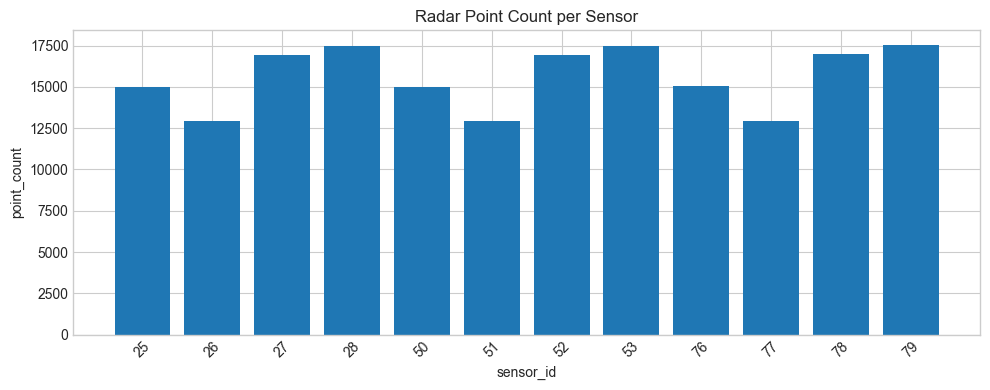

In [33]:
# Point count per radar sensor (table + bar chart)
# Uses sensor_label when available (new capture format), otherwise sensor_id.

count_key = "sensor_label" if "sensor_label" in radar_df.columns else "sensor_id"

radar_point_counts = (
    radar_df.groupby(count_key)
    .size()
    .rename("point_count")
    .reset_index()
    .sort_values(count_key)
)

total_points = int(radar_point_counts["point_count"].sum())
print(f"Grouping key: {count_key}")
print(f"Total radar points: {total_points:,}")

display(radar_point_counts)

plt.figure(figsize=(10, 4))
plt.bar(radar_point_counts[count_key].astype(str), radar_point_counts["point_count"])
plt.title("Radar Point Count per Sensor")
plt.xlabel(count_key)
plt.ylabel("point_count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()